# Figure 6: what rule does the classifier apply in the interpretable bottleneck?

Manuscript figure for the *decision* side of the TetrisCNN reading. Figure 5 showed
that each surviving branch activation is a spin correlator; this one shows that the
readout network's decision boundary, drawn in those same coordinates, is a **simple
low-order surface**. Because each bottleneck coordinate $z_k$ is itself an
affine-plus-higher-order function of known spin correlators, that boundary can be
rewritten directly as a condition on correlators. This is what makes the classifier's
decision readable as physics, rather than as a hyperplane sitting in an opaque latent
space.

**Output.** Two manuscript files, both written under `Plots/`:

- `Fig6_C4.pdf`, produced with the default `RUN_TAG = "C4"`: panel (a) the Ising
  latent, panel (b) the XY decision surface (`fig:decision_boundaries`). This is the
  file the manuscript actually uses, renamed to `Fig6.pdf` on export into
  `final_figures/`. A plain `Fig6.pdf` already sitting in `Plots/` is a stale
  earlier run made with `RUN_TAG = "plain"`, not the file the current caption
  describes; re-running this notebook with the default configuration produces the
  `_C4` file, and that is the one to take.
- `Fig_xy_plane_vs_square_time.pdf`: the linear-vs-quadratic misclassification-rate
  comparison from the "Decision boundary: plane vs quadratic surface" appendix
  (`fig:decision_boundary_plane_square_misclassification`).

### What it reads

Trained run folders under `Plots_data/`, each holding `net1.pt`, `net2.pt` and
`config.json`: one Ising/XY pair for the $C_4$-equivariant architecture
(`Plots_data/Ising_C4_smallkernels_lam3_seed42_p2`,
`Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2`) and a `_plain` counterpart for the
unconstrained one, selected by `RUN_TAG` in the configuration cell below. See
`Plots_data/README.md` for how these folders were extracted from the gitignored
`logs/` tree.

**Scope.** Boundary equations stay in **latent** coordinates $z$. The one correlator fit done here is for the axis
annotation of panel (a), which would otherwise carry a hard-coded constant.


In [1]:
import os

from tetriscnn import PAPER_MPLSTYLE

from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sympy as sp
import torch
from IPython.display import Math, display
from mpl_toolkits.mplot3d.art3d import Poly3DCollection
from skimage import measure
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from torch.utils.data import DataLoader

from tetriscnn.datasets import create_datasets
from tetriscnn.interpret import fit_activation_to_correlators, plateau_index
from tetriscnn.models import ShapeAdaptiveConvNet, SmallModel
from tetriscnn.utils import (
    logistic_penalty_kwargs,
    AttrDict, DEVICE, branch_label, kernel_to_latex_pattern, load_json,
)

from tetriscnn.colors import COLORS, blue_cmap

# Paths below (Plots_data/ in, Plots/ out) are relative to the repository root;
# move there so the notebook runs the same from the root or from notebooks/.
os.chdir(next(p for p in [Path.cwd(), *Path.cwd().parents] if (p / "pyproject.toml").exists()))
Path("Plots/SVG").mkdir(parents=True, exist_ok=True)

## Configuration

Both models are loaded from **run folders**, the level holding `net1.pt`, `net2.pt`
and `config.json`, which for a `partition` experiment is the `partition_{i}` folder.

`RUN_TAG` switches the whole notebook between the C4-equivariant pair and the
non-equivariant one. Everything downstream (how many branches survive, whether panel
(a) is a line or a plane, the axis glyphs, the fitted equations) follows from the loaded
config, so the switch is the only edit needed.

The specific `lambdamax_*/seed_*` folders in `RUNS` are yours to set and are not
assumed anywhere downstream. Note only that the two panels need not come from the
same seed -- they are different physical models -- but if you want the pair
seed-matched for the manuscript, that is a one-line edit here.

In [2]:
RUN_TAG = "C4"          # "C4" (equivariant) or "plain" (non-equivariant)

# Canonical `partition` runs, copied out of logs/ into Plots_data/ (see
# Plots_data/README.md for provenance). All at lambda_max = 3; seed is not
# load-bearing, the C4/plain split and lambda_max are.
RUNS = {
    "C4": {
        "ising": "Plots_data/Ising_C4_smallkernels_lam3_seed42_p2",
        "xy":    "Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2",
    },
    "plain": {
        "ising": "Plots_data/Ising_plain_smallkernels_lam3_seed46_p2",
        "xy":    "Plots_data/XY_XZ_plain_smallkernels_lam3_seed46_p2",
    },
}
PATHS = {m: Path(folder) for m, folder in RUNS[RUN_TAG].items()}

# Which bottleneck coordinates each panel is drawn in. None -> the most active
# branches, ranked by mean |z|. The plain XY run is pinned because the published
# figure used (1x1, 1x2, diag) = [0, 2, 3], whereas ranking by mean |z| would swap
# the diagonal for the vertical domino -- a defensible choice, but not the one the
# manuscript already shows.
BRANCH_OVERRIDE = {
    "C4": {"ising": None, "xy": None},
    "plain": {"ising": None, "xy": [0, 2, 3]},
}[RUN_TAG]

# May a model's latent COLLAPSE to a single coordinate? Panel (a) may -- that is what
# makes it a number line when the Ising bottleneck really is one-dimensional. Panel (b)
# may not: it is a surface panel and needs three coordinates by construction.
#
# The collapse test is by ACCURACY, not by activation magnitude. An earlier version
# collapsed whenever the top branch had a mean|z| more than 3x the runner-up, which is
# wrong for the same reason magnitude-ranked correlator terms are wrong in Figure 5:
# net2 can place large weights on a small-|z| branch, so mean|z| measures scale, not
# predictive importance. On the C4 XY run at lambdamax_3/seed_46 the 1x1 branch leads
# the next by 11.8x while those "small" branches are worth 0.66 -> 0.998 in accuracy,
# so the magnitude rule threw away the entire surface.
ALLOW_COLLAPSE = {"ising": True, "xy": False}
COLLAPSE_TOL = 0.005      # extra coordinates must buy at least this much CV accuracy

# Boundary sweep: degree 1 is the plane, 2-3 the curved alternatives.
#
# The C grid must reach WEAK penalties (10, 100), not stop at 1.0. Whether curvature
# is needed is decided by comparing the best fit at each degree, and if the grid tops
# out while the plane is still being regularized, the comparison measures penalty
# strength rather than geometry: on the C4 Ising latent the plane sits at cv=0.9952
# for every C <= 1 and jumps to 1.0000 at C=10, so a grid ending at 1.0 concludes
# "curvature justified" for a latent that a straight line separates perfectly.
DEGREES = (1, 2, 3)
CS = (0.005, 0.01, 0.02, 0.04, 0.08, 0.2, 1.0, 10.0, 100.0)

# Forward-selection stopping rule for the quotable boundary equation, same shape as
# Figure5.ipynb: build a nested hierarchy up to MAX_TERMS, then keep the
# shortest prefix within PLATEAU_TOL of the path's best, but never below the floor.
MAX_TERMS = 6
PLATEAU_TOL = 0.002     # in CV accuracy, not R^2 -- these paths are much flatter
PLATEAU_FLOOR = 0.95

# The "good enough" bar, and the knob that actually decides equation length here.
#
# PLATEAU_TOL is measured RELATIVE to the best point on the path, so once a path is
# strong all the way along, it demands nearly every term: on the C4 XY boundary the
# path runs 0.941 -> 0.998 and the plateau rule keeps 6 terms purely to come within
# 0.002 of 0.998, though 4 terms already reach 0.993. PLATEAU_FLOOR cannot fix that
# -- it is a lower bound that only ever makes the target stricter.
#
# SUFFICIENT_ACC is an ABSOLUTE bar: once a prefix clears it the search stops and the
# simplest adequate equation wins. Set it to None to fall back to the plateau rule.
SUFFICIENT_ACC = 0.99

# Readability preference among candidate terms. A PURE term involves one coordinate
# (X, Z, X^2, X^3); a CROSS term mixes them (X Y, Y Z, X^2 Y). Cross terms are harder
# to read and harder to interpret physically, so at each forward step the best pure
# candidate is taken UNLESS a cross term beats it by more than this margin in CV
# accuracy. Set to 0.0 for no preference, or to a large number to forbid cross terms
# outright (the path then simply runs out of pure terms).
#
# A soft margin rather than a ban: an interaction that is genuinely load-bearing
# should still be allowed to win, and the printout says when one did and by how much.
CROSS_TERM_MARGIN = 0.02

SEED = 0
OUTDIR = Path("Plots")
OUTDIR.mkdir(exist_ok=True)
(OUTDIR / "survey").mkdir(exist_ok=True)

for m, p in PATHS.items():
    print(f"{m:>6}: {p}\n        exists={p.exists()}")

# Panel (a)'s branch-readout annotation is a CORRELATOR fit, scored by R^2, so it needs
# its own plateau tolerance -- the accuracy tolerance above is far too tight for R^2.
# These match Figure5.ipynb.
CORR_MAX_TERMS = 5
CORR_PLATEAU_TOL = 0.025
CORR_SUFFICIENT = 0.99      # same idea, applied to the branch readout's R^2

# Which boundary panel (b) draws:
#   "forward" -- the forward-selected equation, i.e. the one this notebook quotes
#   "lasso"   -- the LASSO 1-SE pick from the degree/C sweep
#   "plane" / "curved" -- the two objects section 1 compares
# "forward" is the default because it is the boundary the caption states: on the C4
# XY latent it matches the 1-SE fit's cross-validated accuracy to 2e-4 using 4 terms
# instead of 7, so drawing the 1-SE surface would show a boundary nobody quotes.
PANEL_B_FIT = "forward"

# Viewing angle for the 3D panel.
ELEV, AZIM = 25, -65

# Tag every axis glyph with its symmetry group, as `branch_label` does? Off by
# default: within one run every branch has the same architecture, so a "[C_4]" on
# each of three axes is constant clutter that costs real width in a single-column
# figure. The group is still stated where it changes the meaning of a quantity --
# on the correlator symbol of panel (a), which is orbit-averaged.
TAG_GROUP_ON_AXES = False

 ising: Plots_data/Ising_C4_smallkernels_lam3_seed42_p2
        exists=True
    xy: Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2
        exists=True


## Load both trained runs

`load_run` reads `config.json`, rebuilds the two networks, loads the weights and pushes
the whole validation split through in one batch. It returns the snapshots as well as the
activations, because panel (a)'s annotation needs a correlator fit, and it returns
`times` so the misclassified tables can say *when* each failure happened.

No caching. The extraction costs a few seconds per model and a cache keyed on anything
other than the full run path is exactly how the previous version of this analysis ended
up silently reporting a different model than the one configured.

In [3]:
def load_run(run_folder: Path):
    """Config + weights from a run folder, with the val split pushed through the net.

    Returns an AttrDict-flavoured dict holding the config and numpy arrays for the
    snapshots (`x`), bottleneck activations (`z`), readout logits (`out`) and the
    per-sample tuning parameter (`times`). The loader is `shuffle=False` over the whole
    split in a single batch, so every array aligns index-for-index.
    """
    cf = AttrDict()
    cf.update(load_json(str(run_folder), "config.json"))

    # Legacy runs recorded kernels without a stride entry.
    for k in range(len(cf.kernels)):
        if len(cf.kernels[k]) < 5:
            cf.kernels[k].append(1)

    # Point the config at where it was LOADED from, not where it was first saved.
    cf.logdir = cf.seed_folder = str(run_folder)
    cf.return_all_data = False

    _, val_dataset = create_datasets(cf)

    net1 = ShapeAdaptiveConvNet(
        in_channels=val_dataset[0][0].shape[0],
        kernels=cf.kernels,
        equivariant=cf.equivariant,
        hidden_size=cf.hidden_size,
        init=cf.init,
        device=DEVICE,
    ).to(DEVICE)
    net2 = SmallModel(
        [len(cf.kernels), 32, 16, val_dataset.output_dim], device=DEVICE
    ).to(DEVICE)
    net1.load_state_dict(torch.load(run_folder / "net1.pt", map_location=DEVICE))
    net2.load_state_dict(torch.load(run_folder / "net2.pt", map_location=DEVICE))
    net1.eval()
    net2.eval()

    loader = DataLoader(val_dataset, batch_size=len(val_dataset), shuffle=False)
    with torch.no_grad():
        for x, _ in loader:
            x = x.to(DEVICE)
            z = net1(x)
            out = net2(z)

    return {
        "cf": cf,
        "path": run_folder,
        "x": x.cpu().numpy(),
        "z": z.cpu().numpy(),
        "out": out.cpu().numpy(),
        "times": val_dataset.times.cpu().numpy(),
        "group": cf.equivariant_group if getattr(cf, "equivariant", False) else None,
        "channels": ["X", "Z"] if x.shape[1] == 2 else ["Z"],
    }


def active_branches(z, abs_tol=1e-3, rel_tol=1e-3):
    """Branch indices the L1 penalty did not kill.

    A killed branch has mean|z| of order 1e-9, not exactly zero, so a float-epsilon
    threshold lets dead branches through -- and a dead branch has zero variance, which
    turns any downstream fit into garbage. Require both an absolute floor and a
    fraction of the largest branch.
    """
    mags = np.abs(z).mean(axis=0)
    cut = max(abs_tol, rel_tol * mags.max())
    return [k for k in range(z.shape[1]) if mags[k] > cut]

In [4]:
DATA = {m: load_run(p) for m, p in PATHS.items()}


def _cv_acc(X, y, degree=2, n_splits=5, seed=SEED):
    """CV accuracy of a degree-2 logistic boundary on the given coordinates.

    Degree 2 rather than 1 so a coordinate that only helps NON-linearly still counts:
    the question being asked is "does this axis carry signal", not "is it linearly
    separable".
    """
    pipe = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, include_bias=False),
        LogisticRegression(C=1e4, solver="lbfgs", max_iter=20000,
                           class_weight="balanced", random_state=seed),
    )
    cv = cross_val_score(pipe, X, y, scoring="accuracy", n_jobs=-1,
                         cv=StratifiedKFold(n_splits, shuffle=True, random_state=seed))
    return float(cv.mean()), float(cv.std())


def choose_latent(m, d, override, allow_collapse, max_dims=3):
    """Which branches this model's boundary is drawn in.

    Ranks surviving branches by mean |z| and keeps at most `max_dims` -- magnitude is
    a fine way to ORDER candidates, it is only a bad way to decide how many to drop.
    When `allow_collapse`, the reduction to a single coordinate is then tested by
    asking whether the extra coordinates actually buy cross-validated accuracy.
    """
    mags = np.abs(d["z"]).mean(axis=0)
    ranked = sorted(active_branches(d["z"]), key=lambda k: -mags[k])
    if override is not None:
        return list(override)
    cand = ranked[:max_dims]
    if len(cand) == 1 or not allow_collapse:
        return cand

    y = d["out"].argmax(axis=1)
    a1, _ = _cv_acc(d["z"][:, cand[:1]], y)
    ak, sk = _cv_acc(d["z"][:, cand], y)
    gain = ak - a1
    collapse = gain <= max(COLLAPSE_TOL, sk)
    print(f"  [{m}] collapse test: 1D cv={a1:.4f} vs {len(cand)}D cv={ak:.4f} "
          f"(gain {gain:+.4f}, sd {sk:.4f}) -> "
          f"{'collapse to 1D' if collapse else f'keep {len(cand)}D'}")
    return cand[:1] if collapse else cand


LATENT = {m: choose_latent(m, DATA[m], BRANCH_OVERRIDE[m],
                           ALLOW_COLLAPSE.get(m, False)) for m in DATA}

for m, d in DATA.items():
    cf, z = d["cf"], d["z"]
    mags = np.abs(z).mean(axis=0)
    act = active_branches(z)
    print(f"\n{m}  ({cf.dataset}, {cf.task})   equivariant={cf.equivariant} "
          f"group={d['group']}")
    print(f"  {len(cf.kernels)} branches, {len(act)} active, {len(z)} val snapshots, "
          f"class balance {np.bincount(d['out'].argmax(1))}")
    for k in sorted(act, key=lambda k: -mags[k]):
        mark = f" <- latent slot {LATENT[m].index(k)}" if k in LATENT[m] else ""
        print(f"    branch {k:>2}  shape={str(cf.kernels[k][0]):>6} "
              f"mask={str(cf.kernels[k][3]):>20}  mean|z|={mags[k]:.4f}{mark}")
    print(f"  latent: {LATENT[m]}  ->  {len(LATENT[m])}D")


 [LbC] CREATING DATASET: partition 3/27, threshold=1100.0000, total 20895 samples.

[Even Split] Found 28 time points
[Even Split] Samples per time point: min=297, max=1322, median=824.0
[Even Split] LBC class distribution: class 0=2140, class 1=18755
[Even Split] After per-time-point 70/30 split: 14613 train, 6282 val samples


times shape: 14613, labels shape: torch.Size([14613])
times shape: 6282, labels shape: torch.Size([6282])

Using C4-equivariant convolutional branches.



 [LbC] CREATING DATASET: partition 3/12, threshold=625.0000, total 14471 samples.

[Even Split] Found 13 time points
[Even Split] Samples per time point: min=371, max=2574, median=995.0
[Even Split] LBC class distribution: class 0=5287, class 1=9184
[Even Split] After per-time-point 70/30 split: 10124 train, 4347 val samples
times shape: 10124, labels shape: torch.Size([10124])
times shape: 4347, labels shape: torch.Size([4347])

Using C4-equivariant convolutional branches.



ising  (Paris_Ising, partition)   equivariant=True group=C4
  5 branches, 1 active, 6282 val snapshots, class balance [ 659 5623]
    branch  0  shape=[1, 1] mask=                None  mean|z|=0.7668 <- latent slot 0
  latent: [0]  ->  1D

xy  (Paris_XY_XZ, partition)   equivariant=True group=C4
  5 branches, 3 active, 4347 val snapshots, class balance [1469 2878]
    branch  0  shape=[1, 1] mask=                None  mean|z|=0.5150 <- latent slot 0
    branch  1  shape=[2, 1] mask=                None  mean|z|=0.0438 <- latent slot 1
    branch  2  shape=[2, 2] mask=    [[1, 0], [0, 1]]  mean|z|=0.0355 <- latent slot 2
  latent: [0, 1, 2]  ->  3D


## Boundary-fitting machinery

Four pieces:

- `fit_surface`: a polynomial logistic boundary of a given degree with an $L_1$
  penalty, reported with both in-sample and **cross-validated** accuracy. Only the
  latter is comparable across degrees, since a higher degree always improves the
  in-sample fit.
- `boundary_expr`: rebuilds the fitted decision polynomial $F(z)=0$ as an exact SymPy
  expression in the **original, unscaled** coordinates, undoing the `StandardScaler`.
  This is what makes the equation quotable and the isosurface exact.
- `marching_surface`: the $F=0$ isosurface by marching cubes on the polynomial itself,
  rather than by searching `predict_proba`.
- `parsimonious_per_variant`: the one-standard-error rule, which picks the sparsest fit whose CV
  accuracy is within one CV standard deviation of the best. Selecting on raw CV
  accuracy alone always drifts to degree 3 with 15–30 terms for a gain well inside
  fold-to-fold noise, and those surfaces are neither readable nor plottable.

The target `y` throughout is the **network's own predicted class**, `out.argmax(1)`, not a ground-truth label. These surfaces are descriptions of the classifier, so a point
on the wrong side is a snapshot the closed form fails to describe, not one the physics
got wrong.

In [5]:
import re

VAR_NAMES = ["X", "Y", "Z", "U", "V", "W"]
_TOKEN = re.compile(r"^([A-Z])(?:\^(\d+))?$")


def boundary_expr(scaler, clf, feat_names, var_names) -> sp.Expr:
    """The exact decision polynomial F(...) in ORIGINAL (unscaled) coordinates."""
    syms = sp.symbols(" ".join(var_names), real=True)
    syms = (syms,) if isinstance(syms, sp.Symbol) else tuple(syms)
    scaled = {name: (s - float(m)) / float(sd)
              for name, s, m, sd in zip(var_names, syms, scaler.mean_, scaler.scale_)}

    expr = sp.Float(float(clf.intercept_[0]))
    for fname, coef in zip(feat_names, clf.coef_[0]):
        if abs(coef) < 1e-12:
            continue
        term = sp.Float(float(coef))
        for tok in fname.split():
            var, power = _TOKEN.match(tok).groups()
            term *= scaled[var] ** (int(power) if power else 1)
        expr += term
    return expr


def fit_surface(X, y, degree=2, C=0.04, penalty="l1", n_splits=5, seed=SEED):
    """Polynomial logistic boundary; in-sample and cross-validated accuracy."""
    var_names = VAR_NAMES[:X.shape[1]]
    pipe = make_pipeline(
        StandardScaler(),
        PolynomialFeatures(degree=degree, include_bias=False),
        LogisticRegression(**logistic_penalty_kwargs(penalty == "l1"), C=C,
                           solver="liblinear" if penalty == "l1" else "lbfgs",
                           max_iter=20000, class_weight="balanced", random_state=seed),
    )
    pipe.fit(X, y)
    feat_names = pipe.named_steps["polynomialfeatures"].get_feature_names_out(var_names)
    coefs = pipe.named_steps["logisticregression"].coef_[0]
    nonzero = [(n, float(c)) for n, c in zip(feat_names, coefs) if abs(c) > 1e-8]
    cv = cross_val_score(pipe, X, y, scoring="accuracy", n_jobs=-1,
                         cv=StratifiedKFold(n_splits, shuffle=True, random_state=seed))
    return {
        "pipe": pipe, "degree": degree, "C": C, "penalty": penalty,
        "acc": float(pipe.score(X, y)), "cv_mean": float(cv.mean()),
        "cv_std": float(cv.std()), "n_terms": len(nonzero), "n_feats": len(feat_names),
        "terms": nonzero, "feat_names": list(feat_names), "var_names": var_names,
        "expr": boundary_expr(pipe.named_steps["standardscaler"],
                              pipe.named_steps["logisticregression"],
                              feat_names, var_names),
    }


def marching_surface(expr, X, n=(220, 90, 90), pad=(0.15, 0.15, 0.25)):
    """Isosurface F=0 of the exact polynomial, in original coordinates."""
    syms = sp.symbols("X Y Z", real=True)
    rngs = []
    for d, (npts, p) in enumerate(zip(n, pad)):
        lo, hi = X[:, d].min(), X[:, d].max()
        m = p * (hi - lo)
        rngs.append(np.linspace(lo - m, hi + m, npts))
    grid = np.meshgrid(*rngs, indexing="ij")
    F = sp.lambdify(syms, sp.expand(expr), "numpy")(*grid)
    F = np.broadcast_to(np.asarray(F, dtype=float), grid[0].shape)
    if F.min() > 0 or F.max() < 0:
        return None, None
    verts, faces, _, _ = measure.marching_cubes(
        F, level=0, spacing=tuple(r[1] - r[0] for r in rngs))
    return verts + np.array([r[0] for r in rngs]), faces


def parsimonious(rows, key="cv_mean"):
    """One-SE rule: sparsest fit within one CV standard deviation of the best."""
    best = max(rows, key=lambda r: r[key])
    ok = [r for r in rows if r[key] >= best[key] - best["cv_std"]]
    return min(ok, key=lambda r: (r["n_terms"], r["degree"], -r[key]))


def print_table(rows, top=None):
    hdr = (f"{'deg':>4}{'C':>8}{'acc':>9}{'cv_acc':>9}{'+-':>7}{'terms':>8}  formula-terms")
    print(hdr)
    print("-" * len(hdr))
    for r in (rows if top is None else rows[:top]):
        names = ",".join(n for n, _ in r["terms"])
        print(f"{r['degree']:>4}{r['C']:>8.3g}{r['acc']:>9.4f}{r['cv_mean']:>9.4f}"
              f"{r['cv_std']:>7.4f}{r['n_terms']:>5}/{r['n_feats']:<3}  {names[:60]}")


def round_expr(expr, num_digits=3):
    """Round every float in a SymPy expression.

    Coefficients otherwise print as exact rationals with dozens of digits. Numbers
    below the rounding scale are kept in exponential form rather than flushed to zero,
    so a term that is genuinely tiny still shows up as tiny instead of vanishing.
    """
    rounded = {}
    for atom in expr.atoms(sp.Number):
        if abs(atom) > 1 / 10 ** num_digits:
            rounded[atom] = round(atom, num_digits)
        else:
            rounded[atom] = float(f"{float(atom):+.{num_digits}e}")
    return expr.xreplace(rounded)


def latent_matrix(m):
    """Design matrix of the chosen branch activations, and the network's class."""
    d = DATA[m]
    return np.column_stack([d["z"][:, b] for b in LATENT[m]]), d["out"].argmax(axis=1)

## 1. Plane or curved surface?

The question the manuscript needs answered before it draws anything: is the readout's
decision boundary in the bottleneck a **plane**, or does it genuinely curve?

Answering it by tuning the penalty until the fit looks flat would conflate two
different knobs: a degree-2 fit driven to sparsity by a strong penalty is not the same
object as a degree-1 fit, and choosing between them by eye leaves no record in the
output. Here both degrees are fitted over the same grid of penalties and scored by
cross-validated accuracy, so the comparison is explicit and the answer is a number
rather than a setting. The grid deliberately extends to *weak* penalties, so that "best at this
degree" means what it says (see the note on `CS` in the configuration).

In [6]:
SWEEPS, PICKS = {}, {}
for m in DATA:
    X, y = latent_matrix(m)
    rows = [fit_surface(X, y, degree=deg, C=C) for deg in DEGREES for C in CS]
    rows.sort(key=lambda r: (-r["cv_mean"], r["n_terms"]))
    SWEEPS[m] = rows
    PICKS[m] = parsimonious(rows)
    print(f"\n=== {m}   latent {LATENT[m]}  ({len(LATENT[m])}D)")
    print_table(rows, top=6)
    p = PICKS[m]
    print(f"  1-SE pick: degree={p['degree']} C={p['C']:g} acc={p['acc']:.4f} "
          f"cv={p['cv_mean']:.4f} terms={p['n_terms']}")


=== ising   latent [0]  (1D)
 deg       C      acc   cv_acc     +-   terms  formula-terms
------------------------------------------------------------
   1      10   1.0000   1.0000 0.0000    1/1    X
   1     100   1.0000   1.0000 0.0000    1/1    X
   3    0.01   1.0000   1.0000 0.0000    1/3    X^3
   3    0.02   1.0000   1.0000 0.0000    1/3    X^3
   3    0.04   1.0000   1.0000 0.0000    1/3    X^3
   3    0.08   1.0000   1.0000 0.0000    1/3    X^3
  1-SE pick: degree=1 C=10 acc=1.0000 cv=1.0000 terms=1



=== xy   latent [0, 1, 2]  (3D)
 deg       C      acc   cv_acc     +-   terms  formula-terms
------------------------------------------------------------
   2      10   0.9993   0.9993 0.0009    6/9    X,Y,Z,X^2,X Z,Y Z
   2     100   0.9993   0.9991 0.0011    8/9    X,Y,Z,X^2,X Y,X Z,Y Z,Z^2
   3      10   0.9991   0.9984 0.0020    8/19   X,Y,Z,X^2,X Y,X Z,Y Z,X^3
   3     100   0.9995   0.9984 0.0017   17/19   X,Y,Z,X^2,X Y,X Z,Y^2,Y Z,X^3,X^2 Y,X^2 Z,X Y^2,X Y Z,X Z^2,
   2       1   0.9986   0.9975 0.0029    4/9    X,Y,Z,X^2
   3       1   0.9986   0.9972 0.0028    4/19   X,Y,Z,X^2
  1-SE pick: degree=2 C=10 acc=0.9993 cv=0.9993 terms=6


In [7]:
# Plane vs curved, done properly. Two different questions get confused if only one
# number per degree is reported:
#
#   "can a degree-d boundary do the job?"   -> the BEST cv at that degree, C tuned
#   "how simple is the degree-d boundary?"  -> the 1-SE representative
#
# Judging curvature on the 1-SE representatives alone is misleading, because a
# degree-1 fit driven sparse by a strong penalty can underperform a plane that is
# simply fitted properly -- the loss then reads as "a plane cannot do this" when it is
# really "this penalty was too strong". Both columns are shown; the verdict uses the
# best-per-degree figures.
BEST_BY_DEGREE, BY_DEGREE = {}, {}
print(f"{'model':>8}{'degree':>8}{'best cv':>10}{'+-':>8}{'C':>7}   |"
      f"{'1-SE cv':>9}{'terms':>7}{'C':>7}")
print("-" * 74)
for m in DATA:
    BEST_BY_DEGREE[m], BY_DEGREE[m] = {}, {}
    for deg in DEGREES:
        rows = [r for r in SWEEPS[m] if r["degree"] == deg]
        BEST_BY_DEGREE[m][deg] = max(rows, key=lambda r: r["cv_mean"])
        BY_DEGREE[m][deg] = parsimonious(rows)
    for deg in DEGREES:
        b, s = BEST_BY_DEGREE[m][deg], BY_DEGREE[m][deg]
        print(f"{m if deg == DEGREES[0] else '':>8}{deg:>8}{b['cv_mean']:>10.4f}"
              f"{b['cv_std']:>8.4f}{b['C']:>7.3g}   |{s['cv_mean']:>9.4f}"
              f"{s['n_terms']:>7}{s['C']:>7.3g}")
    print()

# Is the curvature worth it? "Worth it" = the best curved fit clears the best plane by
# more than the plane's own fold-to-fold scatter. Anything smaller is a gain we cannot
# distinguish from noise, and the plane is the honest thing to quote.
for m in DATA:
    plane = BEST_BY_DEGREE[m][1]
    curved = max((BEST_BY_DEGREE[m][d] for d in DEGREES if d > 1),
                 key=lambda r: r["cv_mean"])
    d_cv = curved["cv_mean"] - plane["cv_mean"]
    verdict = ("curvature justified" if d_cv > plane["cv_std"]
               else "within noise -- a plane describes it just as well")
    print(f"{m}: best plane cv={plane['cv_mean']:.4f} (sd {plane['cv_std']:.4f}), "
          f"best curved cv={curved['cv_mean']:.4f} (degree {curved['degree']}); "
          f"gain {d_cv:+.4f} -> {verdict}")

   model  degree   best cv      +-      C   |  1-SE cv  terms      C
--------------------------------------------------------------------------
   ising       1    1.0000  0.0000     10   |   1.0000      1     10
               2    1.0000  0.0000      1   |   1.0000      2      1
               3    1.0000  0.0000   0.01   |   1.0000      1   0.01

      xy       1    0.9834  0.0038      1   |   0.9834      3      1
               2    0.9993  0.0009     10   |   0.9993      6     10
               3    0.9984  0.0020     10   |   0.9972      4      1

ising: best plane cv=1.0000 (sd 0.0000), best curved cv=1.0000 (degree 2); gain +0.0000 -> within noise -- a plane describes it just as well
xy: best plane cv=0.9834 (sd 0.0038), best curved cv=0.9993 (degree 2); gain +0.0159 -> curvature justified


## 2. The quotable boundary equation

The 1-SE rule above picks a *fit*; it does not yet give an equation short enough to
print. The LASSO leaves whatever terms survive its penalty, in no particular order of
importance, and the number of them is a side effect of `C` rather than a decision.

So the term choice is ported from `Figure5.ipynb`, where the same problem arose
for correlators. Build a **nested importance hierarchy** by forward selection (the
single most predictive polynomial term, then the best addition given that one, and so
on) then keep the shortest prefix that is already as good as the path gets:

$$k^* = \min\Big\{k : A_k \ge \max\big(\max_j A_j - \texttt{PLATEAU\_TOL},\ \texttt{PLATEAU\_FLOOR}\big)\Big\}$$

with one override in front of it. `PLATEAU_TOL` is measured *relative to the best
point on the path*, which is the right question when the path is weak, but once a
path is strong throughout, it forces almost every term: the C4 XY boundary climbs
$0.941 \to 0.998$, and matching $0.998$ to within $0.002$ costs six terms even though
four already reach $0.993$. `PLATEAU_FLOOR` cannot express "that is good enough",
because the $\max$ only ever makes the target *stricter*.

So `SUFFICIENT_ACC` is an **absolute** bar: if any prefix clears it, the shortest such
prefix wins outright and the plateau comparison is skipped,

$$k^* = \min\{k : A_k \ge \texttt{SUFFICIENT\_ACC}\}
\quad\text{when that set is non-empty.}$$

Both boundaries here clear $0.99$ comfortably, so this is what sets the quoted
equation length; the plateau rule remains the fallback for paths that never get
there. It is implemented as the opt-in `sufficient=` argument of
`tetriscnn.interpret.plateau_index`, so Figure 5 is unaffected unless it opts in too.

Two differences from the Figure 5 version. The score $A$ is **cross-validated accuracy**,
not $R^2$: adding a polynomial term always improves in-sample accuracy, so an in-sample
path would never plateau. And `PLATEAU_TOL` is correspondingly small, because accuracy
paths here are flat to within a few parts in a thousand once the leading term is in.

The plateau is measured against the path *maximum* rather than stopping at the first small gain: that is the rule that matters when terms are only jointly informative. `plateau_index`
is imported from `tetriscnn.interpret`, so both figures cut their equations with literally
the same function.


### Preferring readable terms

One more constraint, and it is about readability rather than fit. Among candidates of
near-equal merit the search should prefer a **pure** term (one coordinate, any power
($X$, $Z$, $X^2$)) over a **cross** term that mixes coordinates ($XY$, $YZ$, $X^2Z$).
A bilinear equation is harder to read and harder to give a physical account of than a
sum of powers, and where two candidates are within noise of each other, that is the
only thing distinguishing them.

This is a soft margin, not a ban: at each step the best pure candidate is taken unless
a cross term beats it by more than `CROSS_TERM_MARGIN` in CV accuracy. An interaction
that genuinely carries the boundary can still win, and the path printout records when
one did and what the best pure alternative would have scored, so the cost of the
preference is visible rather than hidden.

In [8]:
def poly_features(X, degree, var_names):
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    return poly.fit_transform(X), list(poly.get_feature_names_out(var_names))


def _subset_pipe(Xp, y, cols, C=1e4, seed=SEED):
    """Unpenalized logistic fit on a chosen set of polynomial features.

    C is large rather than infinite: the point of the forward path is that the SUPPORT
    is the regularizer, so the coefficients quoted for it should not additionally be
    shrunk. Same reasoning as the unpenalized refit behind Figure 5's equations.
    """
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C, solver="lbfgs", max_iter=20000,
                           class_weight="balanced", random_state=seed),
    )
    pipe.fit(Xp[:, cols], y)
    return pipe


def cv_accuracy(Xp, y, cols, C=1e4, n_splits=5, seed=SEED):
    pipe = make_pipeline(
        StandardScaler(),
        LogisticRegression(C=C, solver="lbfgs", max_iter=20000,
                           class_weight="balanced", random_state=seed),
    )
    cv = cross_val_score(pipe, Xp[:, cols], y, scoring="accuracy", n_jobs=-1,
                         cv=StratifiedKFold(n_splits, shuffle=True, random_state=seed))
    return float(cv.mean())


def is_pure(name):
    """Does this polynomial feature involve a single coordinate?

    `PolynomialFeatures` names terms by space-separated tokens, so "X", "Z^2" and
    "X^3" are one token (pure) while "X Y" and "X^2 Z" are two (cross).
    """
    return len(name.split()) == 1


def forward_boundary_path(Xp, y, max_terms, names, cross_margin=0.0):
    """Greedy forward selection over polynomial features, scored by CV accuracy.

    At each step the best PURE candidate is preferred; a cross term is taken only if
    it beats the best pure one by more than `cross_margin`. The scoring cost is
    unchanged -- every remaining candidate is evaluated either way -- so the
    preference is free, and it only ever reorders terms of near-equal merit.

    Returns one dict per step, carrying the runner-up scores so the printout can show
    what the preference cost (or saved) at each point.
    """
    chosen, remaining, steps = [], list(range(Xp.shape[1])), []
    for _ in range(min(max_terms, Xp.shape[1])):
        scored = {j: cv_accuracy(Xp, y, chosen + [j]) for j in remaining}
        pure = [j for j in remaining if is_pure(names[j])]
        cross = [j for j in remaining if not is_pure(names[j])]
        best_pure = max(pure, key=lambda j: scored[j]) if pure else None
        best_cross = max(cross, key=lambda j: scored[j]) if cross else None

        if best_pure is None:
            pick = best_cross
        elif best_cross is None or scored[best_cross] - scored[best_pure] <= cross_margin:
            pick = best_pure
        else:
            pick = best_cross

        chosen.append(pick)
        remaining.remove(pick)
        steps.append({
            "col": pick, "score": scored[pick], "cross": not is_pure(names[pick]),
            "best_pure": None if best_pure is None else scored[best_pure],
            "best_cross": None if best_cross is None else scored[best_cross],
        })
    return steps


class SubsetBoundary:
    """Adapter presenting a forward-selected fit with the swept fits' interface.

    `fit_surface` returns a pipeline that consumes the RAW latent coordinates, while
    the forward search works on the expanded polynomial design matrix. Wrapping the
    expansion here means the plotting and misclassification code has a single calling
    convention instead of branching on where the fit came from.
    """

    def __init__(self, pipe, degree, cols):
        self.pipe, self.degree, self.cols = pipe, degree, cols

    def _expand(self, X):
        poly = PolynomialFeatures(degree=self.degree, include_bias=False)
        return poly.fit_transform(X)[:, self.cols]

    def decision_function(self, X):
        return self.pipe.decision_function(self._expand(X))

    def predict(self, X):
        return self.pipe.predict(self._expand(X))


def subset_expr(pipe, names, var_names):
    """Decision polynomial of a subset fit, in original (unscaled) coordinates.

    Note this scaler standardizes the POLYNOMIAL features, not the raw coordinates
    (the forward search works on the expanded design matrix), so each monomial is
    un-standardized as a whole rather than variable by variable.
    """
    scaler = pipe.named_steps["standardscaler"]
    clf = pipe.named_steps["logisticregression"]
    syms = {v: sp.Symbol(v, real=True) for v in var_names}
    expr = sp.Float(float(clf.intercept_[0]))
    for name, coef, mu, sd in zip(names, clf.coef_[0], scaler.mean_, scaler.scale_):
        mono = sp.Integer(1)
        for tok in name.split():
            v, p = _TOKEN.match(tok).groups()
            mono *= syms[v] ** (int(p) if p else 1)
        expr += float(coef) * (mono - float(mu)) / float(sd)
    return sp.expand(expr)


FORWARD = {}
for m in DATA:
    X, y = latent_matrix(m)
    degree = PICKS[m]["degree"]
    var_names = VAR_NAMES[:X.shape[1]]
    Xp, names = poly_features(X, degree, var_names)
    steps = forward_boundary_path(Xp, y, MAX_TERMS, names,
                                  cross_margin=CROSS_TERM_MARGIN)
    path = [(st["col"], st["score"]) for st in steps]
    n_keep = plateau_index(path, PLATEAU_TOL, floor=PLATEAU_FLOOR,
                           sufficient=SUFFICIENT_ACC)
    cols = [c for c, _ in path[:n_keep]]
    pipe = _subset_pipe(Xp, y, cols)

    FORWARD[m] = {
        "degree": degree, "cols": cols, "path": path, "steps": steps,
        "n_keep": n_keep,
        "names": [names[c] for c in cols], "all_names": names, "pipe": pipe,
        "Xp": Xp, "var_names": var_names,
        "acc": float(pipe.score(Xp[:, cols], y)),
        "cv_mean": path[n_keep - 1][1],
        "expr": subset_expr(pipe, [names[c] for c in cols], var_names),
    }
    # A fit-shaped view of the same thing, so panel (b) and the misclassification
    # report can take it wherever they take a swept fit.
    FORWARD[m]["fit"] = {
        "pipe": SubsetBoundary(pipe, degree, cols), "expr": FORWARD[m]["expr"],
        "degree": degree, "C": None, "n_terms": n_keep,
        "acc": FORWARD[m]["acc"], "cv_mean": FORWARD[m]["cv_mean"],
        "cv_std": float("nan"),
    }

    print(f"\n=== {m}   degree {degree}, {len(names)} candidate terms "
          f"({', '.join(names)})")
    print(f"   {'step':>4} {'cv_acc':>8} {'gain':>9} {'kind':>6}  term"
          f"   (best pure / best cross this step)")
    prev = 0.0
    for i, st in enumerate(steps, 1):
        mark = "<<" if i == n_keep else "  "
        a, col = st["score"], st["col"]
        alt = "  ".join(
            f"{k}={v:.4f}" for k, v in (("pure", st["best_pure"]),
                                        ("cross", st["best_cross"])) if v is not None)
        print(f"{mark} {i:>4} {a:>8.4f} {a - prev:>+9.4f} "
              f"{'cross' if st['cross'] else 'pure':>6}  {names[col]:<8} {alt}")
        prev = a
    taken = [names[st["col"]] for st in steps[:n_keep] if st["cross"]]
    if taken:
        print(f"   cross terms kept despite the {CROSS_TERM_MARGIN} margin: {taken} "
              f"(each beat the best pure alternative by more than that)")
    f = FORWARD[m]
    why = ("cleared SUFFICIENT_ACC" if SUFFICIENT_ACC is not None
           and f["cv_mean"] >= SUFFICIENT_ACC else "plateau/floor rule")
    print(f"   kept {n_keep} term(s): {f['names']}   "
          f"in-sample acc={f['acc']:.4f}, cv={f['cv_mean']:.4f}  [{why}]")
    if SUFFICIENT_ACC is not None:
        full = path[-1][1]
        print(f"   for comparison, the full {len(path)}-term path ends at "
              f"cv={full:.4f} -- {len(path) - n_keep} extra term(s) for "
              f"{full - f['cv_mean']:+.4f}")
    print(f"   LASSO 1-SE pick for comparison: {PICKS[m]['n_terms']} terms, "
          f"acc={PICKS[m]['acc']:.4f}, cv={PICKS[m]['cv_mean']:.4f}")
    if f["cv_mean"] < PLATEAU_FLOOR:
        print(f"   WARNING: budget exhausted below the floor {PLATEAU_FLOOR} -- "
              f"no adequate short boundary exists in these coordinates.")


=== ising   degree 1, 1 candidate terms (X)
   step   cv_acc      gain   kind  term   (best pure / best cross this step)
<<    1   1.0000   +1.0000   pure  X        pure=1.0000
   kept 1 term(s): ['X']   in-sample acc=1.0000, cv=1.0000  [cleared SUFFICIENT_ACC]
   for comparison, the full 1-term path ends at cv=1.0000 -- 0 extra term(s) for +0.0000
   LASSO 1-SE pick for comparison: 1 terms, acc=1.0000, cv=1.0000



=== xy   degree 2, 9 candidate terms (X, Y, Z, X^2, X Y, X Z, Y^2, Y Z, Z^2)
   step   cv_acc      gain   kind  term   (best pure / best cross this step)
      1   0.9411   +0.9411   pure  Y        pure=0.9411  cross=0.8776
      2   0.9669   +0.0258   pure  Z        pure=0.9669  cross=0.9643
      3   0.9832   +0.0163   pure  X        pure=0.9832  cross=0.9857
<<    4   0.9995   +0.0163   pure  X^2      pure=0.9995  cross=0.9892
      5   0.9995   +0.0000   pure  Y^2      pure=0.9995  cross=0.9993
      6   0.9991   -0.0005   pure  Z^2      pure=0.9991  cross=0.9993
   kept 4 term(s): ['Y', 'Z', 'X', 'X^2']   in-sample acc=0.9995, cv=0.9995  [cleared SUFFICIENT_ACC]
   for comparison, the full 6-term path ends at cv=0.9991 -- 2 extra term(s) for -0.0005
   LASSO 1-SE pick for comparison: 6 terms, acc=0.9993, cv=0.9993


### Coordinate legend

`X`, `Y`, `Z` in the equations above and below are the bottleneck coordinates of the
latent chosen for each model, in slot order. The figure's axes carry the branch glyphs
directly; here they are spelled out so the printed polynomials can be read.

In [9]:
def coord_legend(m):
    d = DATA[m]
    return [(VAR_NAMES[i], b, branch_label(d["cf"], b, full_latex=True))
            for i, b in enumerate(LATENT[m])]


for m in DATA:
    print(f"{m}:")
    for var, b, glyph in coord_legend(m):
        display(Math(rf"{var} \;=\; z\left[{glyph.strip('$')}\right] "
                     rf"\quad\text{{(branch {b})}}"))

ising:


<IPython.core.display.Math object>

xy:


<IPython.core.display.Math object>

<IPython.core.display.Math object>

<IPython.core.display.Math object>

## 3. Simplifying the equation, and what it costs

A boundary is only quotable if its printed form still classifies the way the fitted one
does. `simplify` is free (it rewrites, it does not approximate) but **rounding is
not**, and rounding to one decimal is what makes these equations short enough for a
caption.

So every rounding is checked rather than assumed: the rounded polynomial is evaluated
on the same points as the exact one and the number of points whose predicted class
*flips* is reported. A rounding that flips nothing is safe to print; one that flips a
handful near the boundary is a judgement call the caption should not hide; one that
flips many is wrong.

The check runs at several precisions at once, rather than at a single chosen one, and
for both the plane and the curved boundary.

The **first** cell below reports the equation this notebook quotes and the figure
draws. The **second** is a diagnostic: it applies the same treatment to the plane
and to the LASSO 1-SE fit, so the plane-vs-curved claim of section 1 can be read
as equations rather than taken on trust. The 1-SE equation is usually the longer
of the two, because that rule fixes a penalty and accepts whatever survives it,
while forward selection fixes the accuracy target and asks how few terms reach it.

In [10]:
def eval_boundary(expr, X, var_names):
    """Predicted class of a SymPy boundary, F > 0 -> class 1 (as `pipe.predict`)."""
    syms = sp.symbols(" ".join(var_names), real=True)
    syms = (syms,) if isinstance(syms, sp.Symbol) else tuple(syms)
    f = sp.lambdify(syms, sp.expand(expr), "numpy")
    vals = np.broadcast_to(np.asarray(f(*X.T), dtype=float), (len(X),))
    return (vals > 0).astype(int)


def simplify_report(expr, X, y, var_names, label, digits=(3, 2, 1), show=1):
    """Round an expression progressively, reporting accuracy and flipped predictions.

    `show` is the precision whose expression gets displayed -- the one intended for the
    manuscript. The others are printed as a table so the choice is visibly a tradeoff
    rather than a default.
    """
    exact = sp.simplify(sp.expand(expr))
    pred_exact = eval_boundary(exact, X, var_names)
    print(f"{label}: {len(sp.expand(exact).as_ordered_terms())} terms, "
          f"accuracy {(pred_exact == y).mean():.6f} (exact coefficients)")
    print(f"   {'digits':>7}{'accuracy':>11}{'flipped':>10}   verdict")
    chosen = None
    for nd in digits:
        rounded = round_expr(exact, nd)
        pred = eval_boundary(rounded, X, var_names)
        flips = int((pred != pred_exact).sum())
        verdict = ("identical predictions" if flips == 0
                   else f"{100 * flips / len(y):.3f}% of points flip class")
        print(f"   {nd:>7}{(pred == y).mean():>11.6f}{flips:>10}   {verdict}")
        if nd == show:
            chosen = rounded
    return chosen


# THE quoted boundary: the forward-selected equation, which is also what panel (b)
# draws. Everything in the next cell is a diagnostic for comparison, not a rival.
ROUNDED = {}
for m in DATA:
    X, y = latent_matrix(m)
    f = FORWARD[m]
    print(f"\n=== {m}  --  QUOTED BOUNDARY (drawn in the figure)")
    ROUNDED[m] = simplify_report(f["expr"], X, y, f["var_names"],
                                 f"forward-selected ({f['n_keep']} terms)")
    display(Math(sp.latex(ROUNDED[m]) + r"\;=\;0"))


=== ising  --  QUOTED BOUNDARY (drawn in the figure)
forward-selected (1 terms): 2 terms, accuracy 1.000000 (exact coefficients)
    digits   accuracy   flipped   verdict
         3   1.000000         0   identical predictions
         2   1.000000         0   identical predictions
         1   1.000000         0   identical predictions


<IPython.core.display.Math object>


=== xy  --  QUOTED BOUNDARY (drawn in the figure)
forward-selected (4 terms): 5 terms, accuracy 0.999540 (exact coefficients)
    digits   accuracy   flipped   verdict
         3   0.999540         0   identical predictions
         2   0.999540         0   identical predictions
         1   0.999540         0   identical predictions


<IPython.core.display.Math object>

In [11]:
# DIAGNOSTIC ONLY -- none of these equations is the one the figure quotes.
#
# The same rounding treatment applied to the two objects section 1 compared when
# asking "is a plane enough?": the best plane, and the LASSO 1-SE curved pick. The
# latter is typically LONGER than the forward-selected equation above, because the
# 1-SE rule chooses a penalty and then accepts however many terms survive it, rather
# than choosing a number of terms. The closing line quantifies what that costs.
# Where the latent is 1D there is only one boundary to speak of, so it is skipped.
SURFACES = {}
for m in DATA:
    if len(LATENT[m]) < 3:
        print(f"{m}: {len(LATENT[m])}D latent, no surface comparison to make.\n")
        continue
    X, y = latent_matrix(m)
    var_names = VAR_NAMES[:X.shape[1]]
    SURFACES[m] = {"plane": BY_DEGREE[m][1], "curved": PICKS[m]}
    for name, fit in SURFACES[m].items():
        print(f"\n=== {m} / {name} (degree {fit['degree']}, C={fit['C']:g})"
              f"   [diagnostic]")
        r = simplify_report(fit["expr"], X, y, var_names,
                            f"{name} boundary", digits=(3, 2, 1))
        display(Math(sp.latex(r) + r"\;=\;0"))

    # What the longer LASSO equation actually buys over the quoted one.
    fwd, lasso = FORWARD[m]["fit"], SURFACES[m]["curved"]
    print(f"\n  quoted (forward): {fwd['n_terms']} terms, cv={fwd['cv_mean']:.4f}")
    print(f"  LASSO 1-SE      : {lasso['n_terms']} terms, cv={lasso['cv_mean']:.4f}")
    print(f"  -> {lasso['n_terms'] - fwd['n_terms']:+d} terms for "
          f"{lasso['cv_mean'] - fwd['cv_mean']:+.4f} cv "
          f"(plane cv sd is {BEST_BY_DEGREE[m][1]['cv_std']:.4f}, so this gap is "
          f"{'inside' if abs(lasso['cv_mean'] - fwd['cv_mean']) < BEST_BY_DEGREE[m][1]['cv_std'] else 'outside'} the noise)")

ising: 1D latent, no surface comparison to make.


=== xy / plane (degree 1, C=1)   [diagnostic]
plane boundary: 4 terms, accuracy 0.983667 (exact coefficients)
    digits   accuracy   flipped   verdict
         3   0.983667         0   identical predictions
         2   0.983667         0   identical predictions
         1   0.983897         3   0.069% of points flip class


<IPython.core.display.Math object>


=== xy / curved (degree 2, C=10)   [diagnostic]
curved boundary: 7 terms, accuracy 0.999310 (exact coefficients)
    digits   accuracy   flipped   verdict
         3   0.999310         0   identical predictions
         2   0.999310         0   identical predictions
         1   0.999310         0   identical predictions


<IPython.core.display.Math object>


  quoted (forward): 4 terms, cv=0.9995
  LASSO 1-SE      : 6 terms, cv=0.9993
  -> +2 terms for -0.0002 cv (plane cv sd is 0.0038, so this gap is inside the noise)


## 4. Where the closed form fails

Accuracy alone does not say whether the misses are structured. These tables list every
point the fitted boundary puts on the wrong side of itself, with the physical context
needed to interpret the failure:

- `time`: the raw tuning parameter (acquisition time), *not* rescaled by 1000 as
  `Figure2.ipynb` does for plotting;
- `m_X` / `m_Z`: that snapshot's magnetisation per measurement basis,
  $\sum_i S_i / N$, the same `magnetization()` used in `Figure2.ipynb` applied channel
  by channel;
- the latent coordinates themselves, and `margin` = $|F(z)|$, how far onto the wrong
  side the point fell.

Again: `y_net` is the **network's** class, so a row is a snapshot the equation fails to
describe, not one the physics model got wrong. If the misses cluster at particular
times, the closed form is failing on a specific physical regime rather than uniformly.

In [12]:
def misclassified_table(m, y_hat, signed, sort_by="margin", ascending=False):
    """Points where a fitted boundary disagrees with the network it describes."""
    d = DATA[m]
    X, y = latent_matrix(m)
    bad = np.flatnonzero(y_hat != y)

    df = pd.DataFrame({"sample": bad})
    df["time"] = d["times"][bad]
    for ch, nm in enumerate(d["channels"]):          # magnetisation per basis
        df[f"m_{nm}"] = d["x"][bad, ch].mean(axis=(-2, -1))
    for slot, b in enumerate(LATENT[m]):             # latent coordinates
        df[f"z{b}"] = X[bad, slot]
    df["y_net"] = y[bad]
    df["y_boundary"] = y_hat[bad]
    df["signed"] = signed[bad]
    df["margin"] = np.abs(signed[bad])
    df.attrs["n_total"] = len(y)
    return df.sort_values(sort_by, ascending=ascending).reset_index(drop=True)


def report_misclassified(m, y_hat, signed, label, expected_acc=None):
    df = misclassified_table(m, y_hat, signed)
    n, N = len(df), df.attrs["n_total"]
    d = DATA[m]
    print(f"{label}: {n}/{N} points on the wrong side ({100 * n / N:.2f}%)")
    if expected_acc is not None:
        # The fit's in-sample accuracy is computed on these same points, so this must
        # agree; if it does not, the table was built from a different latent.
        print(f"  consistency: 1 - acc = {1 - expected_acc:.6f}  vs  n/N = {n / N:.6f}")
    if n:
        flow = df.groupby(["y_net", "y_boundary"]).size()
        print("  " + ",  ".join(f"net {a} -> boundary {c}: {k}"
                                for (a, c), k in flow.items()))
        per_t = df.groupby("time").size()
        all_t = pd.Series(d["times"]).value_counts().sort_index()
        print("  by time:  " + ",  ".join(f"t={t:g}: {k}/{all_t[t]}"
                                          for t, k in per_t.items()))
    return df


MIS = {}
for m in DATA:
    X, _ = latent_matrix(m)
    f, fit = FORWARD[m], FORWARD[m]["fit"]
    MIS[m] = report_misclassified(
        m, fit["pipe"].predict(X), fit["pipe"].decision_function(X),
        f"{m} forward-selected ({f['n_keep']} terms)", expected_acc=f["acc"])
    print()

MIS[list(DATA)[-1]].head(10)

ising forward-selected (1 terms): 0/6282 points on the wrong side (0.00%)
  consistency: 1 - acc = 0.000000  vs  n/N = 0.000000

xy forward-selected (4 terms): 2/4347 points on the wrong side (0.05%)
  consistency: 1 - acc = 0.000460  vs  n/N = 0.000460
  net 0 -> boundary 1: 2
  by time:  t=250: 1/528,  t=2000: 1/773



,sample,time,m_X,m_Z,z0,z1,z2,y_net,y_boundary,signed,margin
0,3290,2000.0,-0.047619,0.047619,0.105803,0.025897,0.001100,0,1,0.386815,0.386815
1,542,250.0,-0.333333,0.238095,0.584728,0.006654,0.020694,0,1,0.070471,0.070471


In [13]:
# Plane vs curved, on the model that has a surface: does curvature fix a DIFFERENT set
# of points, or just fewer of the same ones?
for m, fits in SURFACES.items():
    X, _ = latent_matrix(m)
    tables = {}
    for name, fit in fits.items():
        tables[name] = report_misclassified(
            m, fit["pipe"].predict(X), fit["pipe"].decision_function(X),
            f"{m} {name} (degree {fit['degree']})", expected_acc=fit["acc"])
        print()
    a, b = (set(tables[k]["sample"]) for k in ("plane", "curved"))
    print(f"  missed by both: {len(a & b)}   plane only: {len(a - b)}   "
          f"curved only: {len(b - a)}")
    MIS[f"{m}:plane"], MIS[f"{m}:curved"] = tables["plane"], tables["curved"]

MIS.get(f"{list(SURFACES)[0]}:plane", MIS[list(DATA)[-1]]).head(10) if SURFACES else None

xy plane (degree 1): 71/4347 points on the wrong side (1.63%)
  consistency: 1 - acc = 0.016333  vs  n/N = 0.016333
  net 0 -> boundary 1: 20,  net 1 -> boundary 0: 51
  by time:  t=0: 2/534,  t=250: 6/528,  t=500: 16/526,  t=750: 11/317,  t=1000: 5/300,  t=1250: 5/299,  t=1500: 5/253,  t=2000: 8/773,  t=2500: 5/178,  t=3000: 4/239,  t=4000: 2/112,  t=6000: 2/148

xy curved (degree 2): 3/4347 points on the wrong side (0.07%)
  consistency: 1 - acc = 0.000690  vs  n/N = 0.000690
  net 0 -> boundary 1: 1,  net 1 -> boundary 0: 2
  by time:  t=1000: 1/300,  t=2000: 1/773,  t=2500: 1/178

  missed by both: 3   plane only: 68   curved only: 0


,sample,time,m_X,m_Z,z0,z1,z2,y_net,y_boundary,signed,margin
0,1992,1000.0,-0.619048,0.095238,1.004555,0.026806,0.021288,1,0,-6.767283,6.767283
1,539,250.0,-0.523810,0.047619,0.828603,0.031481,0.007181,1,0,-4.330961,4.330961
2,2436,1250.0,0.571429,-0.095238,-0.904469,0.062487,0.030529,1,0,-4.242593,4.242593
3,4069,3000.0,0.714286,0.047619,-1.090837,0.050809,0.046579,1,0,-4.007806,4.007806
4,2608,1500.0,0.619048,0.095238,-0.928734,0.058016,0.032995,1,0,-3.796891,3.796891
5,4170,4000.0,0.523810,0.000000,-0.820646,0.055717,0.031529,1,0,-3.742027,3.742027
6,4334,6000.0,0.619048,-0.190476,-0.995217,0.019998,0.071614,1,0,-3.589115,3.589115
7,3718,2500.0,-0.428571,0.142857,0.713590,0.018541,0.015293,1,0,-2.970314,2.970314
8,1694,750.0,0.904762,0.095238,-1.374878,0.056318,0.043300,1,0,-2.909335,2.909335
9,1307,500.0,0.523810,0.000000,-0.813721,0.047005,0.034692,1,0,-2.885163,2.885163


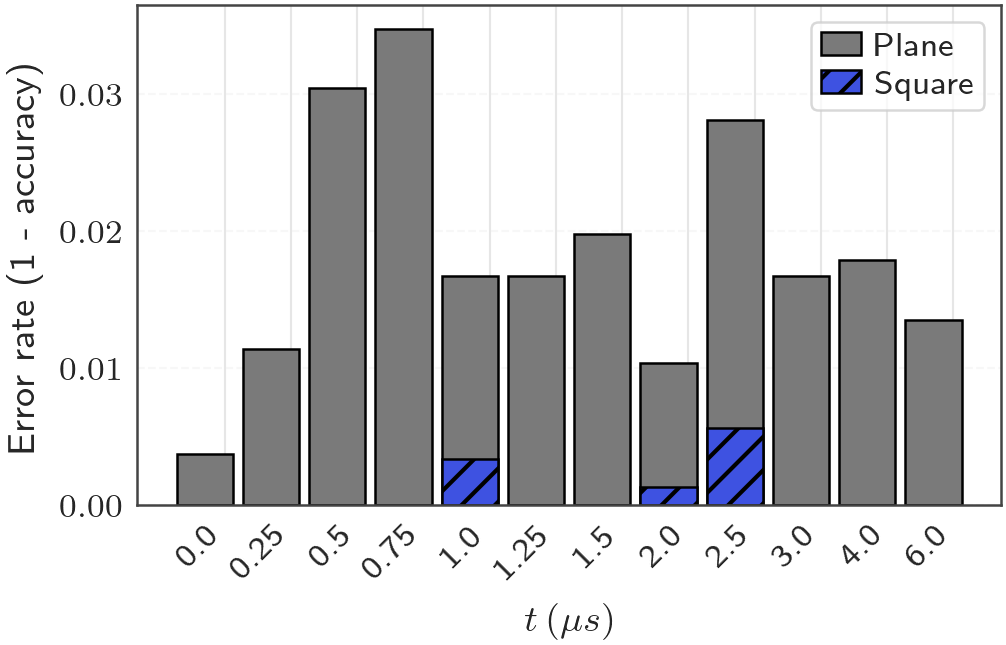

In [14]:
def plot_error_rates_by_timepoint(model="xy", show_percentage=True, figsize=(8, 4)):
    """
    Plot error rates (misclassification rates) for plane vs curved fits by timepoint.

    Filled bars for plane misses, hatched bars for curved misses.

    Args:
        model: "ising" or "xy"
        show_percentage: bool, if True show as %, if False as decimal
        figsize: tuple
    """
    from collections import defaultdict
    from matplotlib import gridspec

    error_rates = {"plane": defaultdict(lambda: (0, 0)), "curved": defaultdict(lambda: (0, 0))}

    # Extract from MIS dataframes (created in previous cell)
    for fit_type in ["plane", "curved"]:
        key = f"{model}:{fit_type}"
        if key not in MIS:
            continue

        df = MIS[key]
        d = DATA[model]

        # Count errors per timepoint
        time_groups = df.groupby("time").size()
        for time, count in time_groups.items():
            N_at_time = (d["times"] == time).sum()
            error_rates[fit_type][time] = (count, N_at_time)

    # Collect timepoints; use the union so both bars sit on the same x-axis even
    # where one fit has zero errors at a given time
    all_times = sorted(set(error_rates["plane"].keys()) | set(error_rates["curved"].keys()))

    def rate(fit_type, t):
        errs, total = error_rates[fit_type].get(t, (0, 0))
        if total == 0:
            return 0.0
        r = errs / total
        return r * 100 if show_percentage else r

    plane_rates = [rate("plane", t) for t in all_times]
    curved_rates = [rate("curved", t) for t in all_times]

    # Plot
    plt.style.use(PAPER_MPLSTYLE)

    SINGLE_WIDTH = 3.4
    DOUBLE_WIDTH = 6.80914
    golden_ratio = (1 + np.sqrt(5)) / 2

    fig = plt.figure(figsize=(SINGLE_WIDTH, SINGLE_WIDTH / golden_ratio * 1.045) )

    gs = gridspec.GridSpec(1, 1, figure=fig,
                        )

    ax = fig.add_subplot(gs[0, 0])
    x = np.arange(len(all_times))
    width = 0.85

    # Filled bars for plane
    ax.bar(x, plane_rates, width, label="Plane",
           color=COLORS["gray"], edgecolor="black")

    # Hatched bars for curved
    ax.bar(x, curved_rates, width, label="Square",
           color=COLORS["blue"], hatch="///", edgecolor="black")


    ax.set_xlabel(r"$t\,(\mu s)$")
    ax.set_ylabel(r"Error rate (\%)" if show_percentage else "Error rate (1 - accuracy)")
    ax.set_xticks(x + 0.3)
    ax.set_xticklabels([str(t / 1000) for t in all_times], rotation=45, ha='right')
    ax.legend()
    ax.grid(axis="y", alpha=0.3, linestyle="--")

    return fig, ax

# Generate plot
if "xy" in SURFACES:
    fig_xy_errors, ax_xy = plot_error_rates_by_timepoint(model="xy", show_percentage=False)

    fig_xy_errors.savefig("Plots/Fig_xy_plane_vs_square_time.pdf")
    plt.show()

## 5. The manuscript figure

A tall single-column figure, panel (a) above panel (b), using `paper.mplstyle` for the
manuscript's LaTeX typography.

Panel (a) is **adaptive**. The Ising bottleneck collapses under the L1 penalty, and how
far it collapses depends on the run: the C4 model at $\lambda_{\max}=3$ keeps a single
$1\times1$ branch, so its latent really is a number line, while a weaker penalty leaves
a second branch worth an axis. `choose_latent` decides which, and the panel is drawn to
match rather than projecting a 2D latent onto one axis and hoping.

The annotation on panel (a) is **generated, not typed**. A hard-coded equation and
threshold would belong to one specific run and be silently wrong for any other, so the
branch readout comes from `fit_activation_to_correlators` with the same forward-selection
cut as Figure 5, and the threshold is read off the fitted boundary. Switching `RUN_TAG`
regenerates both.

In [15]:
plt.style.use(PAPER_MPLSTYLE)

SINGLE_WIDTH = 3.4
DOUBLE_WIDTH = 6.80914
GOLDEN = (1 + np.sqrt(5)) / 2

CLASS_COLS = [COLORS["gray"], COLORS["blue"]]
MAX_PTS = 3000          # scatter subsample; the full split smears into a solid block

The cell below is what prints the two numbers the main text quotes for the Ising
panel: a boundary threshold at $z[\blacksquare] \approx -0.837$ and, after inverting
the branch's linear readout onto its single correlator, a $Z$-magnetization threshold
$C^Z[\blacksquare] \approx 0.387$ ("The Ising bottleneck is 1D" in the main text). Both
values are computed here from the loaded run rather than hand-copied, so they track
whichever run `RUN_TAG` currently points at instead of silently going stale.


In [16]:
def glyph(m, b, tag=None):
    """LaTeX branch glyph, optionally group-tagged (see TAG_GROUP_ON_AXES)."""
    tag = TAG_GROUP_ON_AXES if tag is None else tag
    label = (branch_label(DATA[m]["cf"], b, full_latex=True) if tag else
             kernel_to_latex_pattern(DATA[m]["cf"].kernels[b], equation_env=False,
                                     full_latex=True))
    return label.strip("$")


def axis_label(m, b):
    return rf"$z\left[{glyph(m, b)}\right]$"


def correlator_equation(m, b, precision=2):
    """Branch readout onto its correlators, cut by forward selection + plateau.

    The same routine and the same stopping rule as Figure 5, so the equation annotating
    panel (a) is the one that figure would quote for this branch. Returns the LaTeX
    string plus the fit, or None if no adequate short form exists.
    """
    d = DATA[m]
    probe = fit_activation_to_correlators(
        d["x"], d["z"][:, b], d["cf"].kernels[b], channel_names=d["channels"],
        group=d["group"], verbose=False)
    res = fit_activation_to_correlators(
        d["x"], d["z"][:, b], d["cf"].kernels[b], channel_names=d["channels"],
        group=d["group"], select_terms=min(CORR_MAX_TERMS, len(probe["patterns"])),
        select_strategy="forward", plateau_tol=CORR_PLATEAU_TOL,
        plateau_floor=PLATEAU_FLOOR, plateau_sufficient=CORR_SUFFICIENT,
        verbose=False)

    # For an equivariant branch the fitted feature is the ORBIT AVERAGE, not the
    # correlator of the canonical footprint; a bare C would misstate it. Channel and
    # group go into ONE superscript -- writing them as two (C^{Z}^{C_4}) is a LaTeX
    # double-superscript error, which usetex rejects outright.
    marks = []
    if len(d["channels"]) == 1:          # basis is only worth naming when unambiguous
        marks.append(d["channels"][0])
    # if d["group"] is not None:
    
    base = "C"
    # Built by concatenation, not an f-string: Python 3.11 forbids backslashes inside
    # f-string expressions, and every piece here is a LaTeX escape.
    sym = base + ("^{\," + ",\,".join(marks) + "}" if marks else "")

    coefs = np.asarray(res["selected_coefficients"], dtype=float)
    parts = []
    for i, (c, p) in enumerate(zip(coefs[1:], res["selected_patterns"])):
        body = rf"{abs(c):.{precision}f}\, {sym}\left[{p.strip('$')}\right]"
        parts.append((("-" if c < 0 else "") + body) if i == 0
                     else f"{'-' if c < 0 else '+'} {body}")
    parts.append(f"{'-' if coefs[0] < 0 else '+'} {abs(coefs[0]):.{precision}f}")
    tex = (rf"z\left[{glyph(m, b)}\right] \approx " + " ".join(parts))
    return {"tex": tex, "res": res, "sym": sym, "coefs": coefs}


def boundary_roots(expr, var, lo, hi):
    """Real roots of F=0 inside the data range -- the thresholds of a 1D boundary."""
    out = []
    for s in sp.solve(sp.Eq(expr, 0), sp.Symbol(var, real=True)):
        v = complex(s)
        if abs(v.imag) < 1e-9 and lo <= v.real <= hi:
            out.append(float(v.real))
    return sorted(out)


ANNOT = {}
for m in DATA:
    if len(LATENT[m]) != 1:
        continue
    b = LATENT[m][0]
    X, _ = latent_matrix(m)
    eq = correlator_equation(m, b, precision=3)
    roots = boundary_roots(FORWARD[m]["expr"], "X", X[:, 0].min(), X[:, 0].max())
    ann = {"branch": b, "eq": eq, "roots": roots, "corr": None}

    # Invert the readout to say what the threshold IS physically. Only meaningful when
    # the equation is a single correlator: with two or more terms one z value does not
    # determine one correlator value.
    if roots and len(eq["res"]["selected_terms"]) == 1:
        c0, c1 = eq["coefs"][0], eq["coefs"][1]
        ann["corr"] = (roots[0] - c0) / c1
        ann["corr_tex"] = eq["sym"] + rf"\left[{eq['res']['selected_patterns'][0].strip('$')}\right]"
    ANNOT[m] = ann

    print(f"{m}: branch {b}, readout R^2={eq['res']['selected_r_squared']:.4f} "
          f"({len(eq['res']['selected_terms'])} term(s))")
    display(Math(eq["tex"] + rf"\quad (R^2={eq['res']['selected_r_squared']:.3f})"))
    print(f"  boundary thresholds in z: {[round(r, 4) for r in roots]}")
    if ann["corr"] is not None:
        print(f"  -> threshold in correlator units: {ann['corr']:.4f}")

ising: branch 0, readout R^2=1.0000 (1 term(s))


<IPython.core.display.Math object>

  boundary thresholds in z: [-0.8374]
  -> threshold in correlator units: 0.3873


In [17]:
def _subsample(n, rng_seed=SEED, max_pts=MAX_PTS):
    rng = np.random.default_rng(rng_seed)
    return rng.choice(n, size=min(max_pts, n), replace=False)


def draw_latent_1d(m, ax, legend=True, eq_fontsize=7):
    """Panel (a), collapsed bottleneck: the classes strung out along one branch axis.

    The axis label is the branch's generated correlator equation, which is a good deal
    wider than the hand-written one it replaces (it carries a group-averaged symbol),
    so it is set smaller than the body font. `ylim` is set explicitly to reserve room
    above the line for the threshold callout -- with autoscaling the callout lands
    outside the axes and gets clipped by `savefig`.
    """
    X, _ = latent_matrix(m)
    y = DATA[m]["out"].argmax(axis=1)
    ann = ANNOT[m]

    ax.scatter(X[:, 0], np.zeros_like(X[:, 0]),
               color=[CLASS_COLS[c] for c in y], s=16, alpha=0.1)
    ax.set_yticks([])
    ax.set_ylim(-0.1, 0.1)
    ax.set_frame_on(False)
    ax.spines["bottom"].set_visible(True)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_position(("data", 0))
    ax.set_facecolor("white")
    ax.grid(color="white")

    ax.set_xlabel(rf"$z\,[{ann['eq']['res']['patterns'][0][1:-1]}]$", fontsize=eq_fontsize)
    ax.annotate("", xy=(ax.get_xlim()[1], 0), xytext=(ax.get_xlim()[0], 0),
                xycoords="data", zorder=0,
                arrowprops=dict(arrowstyle="-|>", color="black", lw=2,
                                mutation_scale=15, alpha=0.5))

    if ann["roots"]:
        t = ann["roots"][0]
        ax.vlines(t, -0.01, 0.01, lw=2, color="blue")
        text = rf"$z\,[{ann['eq']['res']['patterns'][0][1:-1]}]={t:.3f}$"
        if ann["corr"] is not None:
            text += "\n" + rf"${ann['corr_tex']}={ann['corr']:.3f}$"
        offset = 20
        arrowprops = dict(
            arrowstyle="->",
            connectionstyle="angle,angleA=0,angleB=90,rad=10",
            lw=2,
            color="k",
        )
        bbox = dict(boxstyle="round", fc="0.8", color="k")
        ax.annotate(text, (t, 0.006), xytext=(-4 * offset, offset), textcoords="offset points",
                    fontsize=6.5, bbox=bbox,
                    arrowprops=arrowprops)
    if legend:
        handles = [plt.Line2D([0], [0], marker="o", color="w", markersize=5,
                              markerfacecolor=CLASS_COLS[1 - i], label=f"Phase {i + 1}")
                   for i in (0, 1)]
        ax.legend(handles=handles, loc="upper right", fontsize=6.5,
                  handletextpad=0.3, borderpad=0.3)
    return ax


def draw_latent_2d(m, ax, legend=True):
    """Panel (a) when two branches survive: scatter plus the zero contour."""
    X, y = latent_matrix(m)
    fit = FORWARD[m]
    sub = _subsample(len(y))
    for cls, col in enumerate(CLASS_COLS):
        sel = y[sub] == cls
        ax.scatter(X[sub][sel, 0], X[sub][sel, 1], color=col, s=6, alpha=0.35,
                   linewidths=0, label=f"Phase {cls + 1}")

    pad = 0.05
    xs = np.linspace(X[:, 0].min() - pad, X[:, 0].max() + pad, 400)
    ys = np.linspace(X[:, 1].min() - pad, X[:, 1].max() + pad, 400)
    XX, YY = np.meshgrid(xs, ys)
    F = sp.lambdify(sp.symbols("X Y", real=True), sp.expand(fit["expr"]), "numpy")
    ax.contour(XX, YY, np.broadcast_to(np.asarray(F(XX, YY), dtype=float), XX.shape),
               levels=[0], colors=[COLORS["blue"]], linewidths=1.4)

    ax.set_xlabel(axis_label(m, LATENT[m][0]))
    ax.set_ylabel(axis_label(m, LATENT[m][1]))
    if legend:
        ax.legend(markerscale=2, loc="best")
    return ax


def draw_surface(m, ax, fit):
    """Panel (b): 3D scatter split by the surface, with the exact F=0 isosurface."""
    if len(LATENT[m]) < 3:
        # Without this the failure is an IndexError from LATENT[m][2], which says
        # nothing about the cause.
        raise ValueError(
            f"panel (b) needs 3 latent coordinates but {m!r} has {len(LATENT[m])} "
            f"({LATENT[m]}). Either the run has fewer than 3 surviving branches, or "
            f"ALLOW_COLLAPSE[{m!r}] is True and the collapse test fired. Set "
            f"BRANCH_OVERRIDE[{RUN_TAG!r}][{m!r}] to pin three branches explicitly.")
    X, y = latent_matrix(m)
    sub = _subsample(len(y))
    signed = fit["pipe"].decision_function(X)

    # Points behind the surface first, the surface, then points in front: the only way
    # to get sane occlusion out of matplotlib's 3D engine.
    for cls, col in enumerate(CLASS_COLS):
        sel = (y[sub] == cls) & (signed[sub] < 0)
        ax.scatter(*X[sub][sel].T, color=col, alpha=0.25, s=12,
                   depthshade=False, zorder=1)

    verts, faces = marching_surface(fit["expr"], X)
    if verts is not None:
        tris = verts[faces]
        tz = tris[:, :, 2].mean(axis=1)
        fc = blue_cmap(0.1 + 0.5 * (tz - tz.min()) / max(np.ptp(tz), 1e-12))
        fc[:, 3] = 0.42
        ax.add_collection3d(Poly3DCollection(tris, facecolors=fc, linewidths=0,
                                             antialiased=True, zorder=2))

    for cls, col in enumerate(CLASS_COLS):
        sel = (y[sub] == cls) & (signed[sub] >= 0)
        ax.scatter(*X[sub][sel].T, color=col, alpha=0.55, s=12, edgecolors="k",
                   linewidths=0.1, depthshade=False, zorder=3)

    ax.set_xlabel(axis_label(m, LATENT[m][0]), labelpad=-2)
    ax.set_ylabel(axis_label(m, LATENT[m][1]), labelpad=-2)
    ax.set_zlabel(axis_label(m, LATENT[m][2]), labelpad=-4)
    ax.tick_params(labelsize=6, pad=-1)
    ax.locator_params(nbins=5)   # mplot3d defaults to ~9 ticks per axis
    ax.set_box_aspect(None, zoom=0.95)
    ax.view_init(elev=ELEV, azim=AZIM)
    return ax

(a) ising: 1D latent, branches [0]
(b) xy: forward boundary, degree 2, acc=0.9995, cv=0.9995, 4 terms


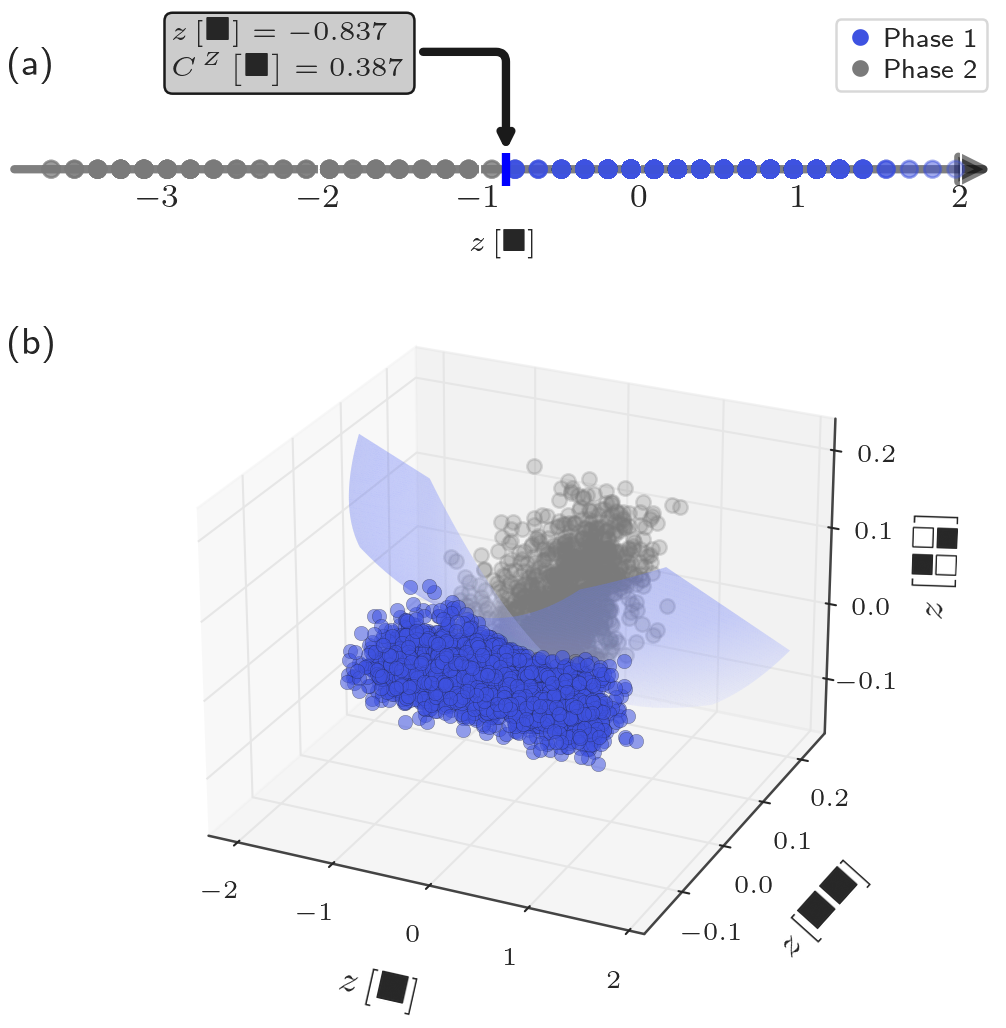

In [18]:
import matplotlib.gridspec as gridspec

PANEL_A, PANEL_B = "ising", "xy"
panel_b_fit = {"forward": FORWARD[PANEL_B]["fit"], "lasso": PICKS[PANEL_B],
               **SURFACES.get(PANEL_B, {})}[PANEL_B_FIT]

fig = plt.figure(figsize=(SINGLE_WIDTH, 1.7 * SINGLE_WIDTH / GOLDEN))
gs = gridspec.GridSpec(2, 1, figure=fig, height_ratios=[1, 2.2])

# A 3D panel needs 3 coordinates; fall back loudly rather than crashing, so a run
# with a thinner bottleneck still produces a figure and says so.
if len(LATENT[PANEL_B]) >= 3:
    ax_b = fig.add_subplot(gs[1], projection="3d", computed_zorder=False)
    draw_surface(PANEL_B, ax_b, panel_b_fit)
else:
    print(f"!! {PANEL_B} latent is {len(LATENT[PANEL_B])}D ({LATENT[PANEL_B]}): "
          f"drawing a {min(2, len(LATENT[PANEL_B]))}D panel (b) instead of a surface.")
    ax_b = fig.add_subplot(gs[1])
    (draw_latent_2d if len(LATENT[PANEL_B]) == 2 else draw_latent_1d)(PANEL_B, ax_b)
# The 3D axes are positioned explicitly rather than left to the gridspec:
# mplot3d reserves a large invisible margin around the cube, so a gridspec
# cell of the right size still renders a small plot.
if ax_b.name == "3d":
    ax_b.set_position([0.02, 0.04, 0.98, 0.72])

ax_a = fig.add_subplot(gs[0])
if len(LATENT[PANEL_A]) == 1:
    draw_latent_1d(PANEL_A, ax_a)
else:
    draw_latent_2d(PANEL_A, ax_a)

fig.text(0.015, 0.95, "(a)", ha="left", va="top", fontsize=9)
fig.text(0.015, 0.69, "(b)", ha="left", va="top", fontsize=9)

print(f"(a) {PANEL_A}: {len(LATENT[PANEL_A])}D latent, branches {LATENT[PANEL_A]}")
print(f"(b) {PANEL_B}: {PANEL_B_FIT} boundary, degree {panel_b_fit['degree']}, "
      f"acc={panel_b_fit['acc']:.4f}, cv={panel_b_fit['cv_mean']:.4f}, "
      f"{panel_b_fit['n_terms']} terms")

In [19]:
fig.savefig(OUTDIR / f"Fig6{'' if RUN_TAG == 'plain' else '_' + RUN_TAG}.pdf")
print(f"wrote {OUTDIR / ('Fig6' + ('' if RUN_TAG == 'plain' else '_' + RUN_TAG))}.pdf")

wrote Plots/Fig6_C4.pdf


## Provenance

Printed so every number quotable from this figure can be traced to the run that
produced it.

In [20]:
print(f"RUN_TAG         : {RUN_TAG}")
for m in DATA:
    d, f = DATA[m], FORWARD[m]
    print(f"\n[{m}]")
    print(f"  run folder    : {d['path']}")
    print(f"  dataset/task  : {d['cf'].dataset} / {d['cf'].task}")
    print(f"  equivariant   : {d['cf'].equivariant}  group={d['group']}")
    print(f"  val snapshots : {len(d['z'])}  latent branches {LATENT[m]}")
    print(f"  1-SE pick     : degree {PICKS[m]['degree']}, C={PICKS[m]['C']:g}, "
          f"{PICKS[m]['n_terms']} terms, acc={PICKS[m]['acc']:.4f}, "
          f"cv={PICKS[m]['cv_mean']:.4f}")
    print(f"  forward eq    : {f['n_keep']} terms {f['names']}, "
          f"acc={f['acc']:.4f}, cv={f['cv_mean']:.4f}")
    print(f"  misdescribed  : {len(MIS[m])}/{len(d['z'])} points")
print(f"\nselection       : forward, budget={MAX_TERMS}, tol={PLATEAU_TOL}, "
      f"floor={PLATEAU_FLOOR}, sufficient={SUFFICIENT_ACC}")

RUN_TAG         : C4

[ising]
  run folder    : Plots_data/Ising_C4_smallkernels_lam3_seed42_p2
  dataset/task  : Paris_Ising / partition
  equivariant   : True  group=C4
  val snapshots : 6282  latent branches [0]
  1-SE pick     : degree 1, C=10, 1 terms, acc=1.0000, cv=1.0000
  forward eq    : 1 terms ['X'], acc=1.0000, cv=1.0000
  misdescribed  : 0/6282 points

[xy]
  run folder    : Plots_data/XY_XZ_C4_smallkernels_lam3_seed46_p2
  dataset/task  : Paris_XY_XZ / partition
  equivariant   : True  group=C4
  val snapshots : 4347  latent branches [0, 1, 2]
  1-SE pick     : degree 2, C=10, 6 terms, acc=0.9993, cv=0.9993
  forward eq    : 4 terms ['Y', 'Z', 'X', 'X^2'], acc=0.9995, cv=0.9995
  misdescribed  : 2/4347 points

selection       : forward, budget=6, tol=0.002, floor=0.95, sufficient=0.99


This section is **supporting material**, not a manuscript figure: `Fig6_ood_2col.pdf`
is not placed by any `\includegraphics` in the paper. It exists because the analysis
below backs a specific claim in the symbolic-regression appendix (App. I 2,
the paragraph following the reference to "Fitting the decision boundary"): that the
polynomial decision-boundary approximation used in the main text reproduces the
TetrisCNN class predictions with $100\%$ accuracy on all three out-of-distribution
probe families, unlike the PySR fits to the full network logit, which generalize far
less cleanly. The cells below are what produce that comparison, for both the Ising and
the XY boundary.


## 6. Out-of-distribution robustness of the latent boundary

App. I (`FiguresApp_I.ipynb`) puts the *symbolic-regression* route through an
out-of-distribution test before trusting it: fit on validation snapshots, then check
whether the fitted form still tracks the network on synthetic spin configurations it
never trained on. The architecture-native route drawn in this notebook -- a decision
boundary fitted directly in the bottleneck, not a PySR equation -- deserves the same
scrutiny. This section reuses the *same* synthetic probes
(`tetriscnn.synthetic_configs.generate_{paramagnetic,ferromagnetic,antiferromagnetic}_configs`,
four flips, `2500` samples per family) and reports the same two scores, `R^2` and the
Spearman rank correlation `rho`, against the network's own continuous decision variable
(`logit_1 - logit_0`, its analogue of the "classification logit" App. I regresses).

One difference from App. I: a logistic boundary is fit to reproduce the network's
*class*, not its logit value, so its raw `decision_function` lives on an arbitrary scale
and sign convention. It is calibrated once, by an ordinary least-squares line fit to the
network's logit difference **on validation data only**, before any `R^2` below is
computed -- `rho` needs no such calibration, since it is invariant to any monotonic
rescaling. This keeps the in-distribution/out-of-distribution split honest: the
calibration, like the boundary itself, only ever sees validation snapshots.

In [21]:
# The boundary objects (`FORWARD[m]["fit"]["pipe"]`, the `SWEEPS[m]` sweep) only need
# `net1`/`net2` to score points already in `DATA[m]`; OOD testing needs the actual
# networks back, since `load_run` did not keep them. Rebuilt here rather than changing
# `load_run`, so this section can be dropped without touching anything above it.
def load_nets(run_folder, cf, in_channels):
    net1 = ShapeAdaptiveConvNet(
        in_channels=in_channels, kernels=cf.kernels, equivariant=cf.equivariant,
        hidden_size=cf.hidden_size, init=cf.init, device=DEVICE,
    ).to(DEVICE)
    net2 = SmallModel([len(cf.kernels), 32, 16, 2], device=DEVICE).to(DEVICE)
    net1.load_state_dict(torch.load(Path(run_folder) / "net1.pt", map_location=DEVICE))
    net2.load_state_dict(torch.load(Path(run_folder) / "net2.pt", map_location=DEVICE))
    net1.eval()
    net2.eval()
    return net1, net2


NETS = {m: load_nets(DATA[m]["path"], DATA[m]["cf"], DATA[m]["x"].shape[1]) for m in DATA}

# Sanity check: the rebuilt pair must reproduce load_run's own stored (z, out) exactly,
# or the OOD numbers below would be scored against the wrong network.
for m in DATA:
    net1, net2 = NETS[m]
    with torch.no_grad():
        x = torch.tensor(DATA[m]["x"], dtype=torch.float32, device=DEVICE)
        z_check = net1(x).cpu().numpy()
        out_check = net2(net1(x)).cpu().numpy()
    print(f"{m}: reload matches load_run to "
          f"{max(np.abs(z_check - DATA[m]['z']).max(), np.abs(out_check - DATA[m]['out']).max()):.2e}")


Using C4-equivariant convolutional branches.

Using C4-equivariant convolutional branches.


ising: reload matches load_run to 0.00e+00
xy: reload matches load_run to 0.00e+00


In [22]:
from tetriscnn.synthetic_configs import (
    generate_paramagnetic_configs, generate_ferromagnetic_configs,
    generate_antiferromagnetic_configs,
)

OOD_N_SAMPLES = 2500   # matches App. I's sr_config.gen_samples
OOD_NUM_FLIPS = 4      # matches App. I's sr_config.num_flips
OOD_SEED = SEED        # this notebook's own seed (0), for reproducibility


def generate_ood_probes(m):
    """The three synthetic families, at this model's own lattice size and channel count.

    Single-channel (Ising) models get one draw per family. Two-channel (XY, X/Z) models
    follow `generate_all_generalization_configs`'s convention: the Z-channel carries the
    named phase, the X-channel a complementary/disordered signal (paramagnetic X for the
    ordered Z families, ferromagnetic X for the disordered paramagnetic one).
    """
    d = DATA[m]
    grid_shape = d["x"].shape[2:]
    n_channels = d["x"].shape[1]
    rng = np.random.default_rng(OOD_SEED)
    z_para = generate_paramagnetic_configs(grid_shape, OOD_N_SAMPLES, DEVICE, rng)
    z_ferro = generate_ferromagnetic_configs(grid_shape, OOD_N_SAMPLES, OOD_NUM_FLIPS, DEVICE, rng)
    z_anti = generate_antiferromagnetic_configs(grid_shape, OOD_N_SAMPLES, OOD_NUM_FLIPS, DEVICE, rng)
    if n_channels == 1:
        return {"paramagnetic": z_para, "ferromagnetic": z_ferro, "antiferromagnetic": z_anti}
    x_for_ferro = generate_paramagnetic_configs(grid_shape, OOD_N_SAMPLES, DEVICE, rng)
    x_for_anti = generate_paramagnetic_configs(grid_shape, OOD_N_SAMPLES, DEVICE, rng)
    x_for_para = generate_ferromagnetic_configs(grid_shape, OOD_N_SAMPLES, OOD_NUM_FLIPS, DEVICE, rng)
    return {
        "paramagnetic": torch.cat([x_for_para, z_para], dim=1),
        "ferromagnetic": torch.cat([x_for_ferro, z_ferro], dim=1),
        "antiferromagnetic": torch.cat([x_for_anti, z_anti], dim=1),
    }


OOD_RAW = {}
for m in DATA:
    net1, net2 = NETS[m]
    probes = generate_ood_probes(m)
    OOD_RAW[m] = {}
    for fam, x_gen in probes.items():
        with torch.no_grad():
            z_gen = net1(x_gen)
            out_gen = net2(z_gen)
        OOD_RAW[m][fam] = {"z": z_gen.cpu().numpy(), "out": out_gen.cpu().numpy()}
    print(f"{m}: OOD probes -> " +
          ", ".join(f"{fam} {v['z'].shape}" for fam, v in OOD_RAW[m].items()))

ising: OOD probes -> paramagnetic (2500, 5), ferromagnetic (2500, 5), antiferromagnetic (2500, 5)


xy: OOD probes -> paramagnetic (2500, 5), ferromagnetic (2500, 5), antiferromagnetic (2500, 5)


In [23]:
from scipy.stats import spearmanr
from sklearn.metrics import r2_score


def net_logit_diff(out):
    """The network's own continuous decision variable -- App. I's role for the
    classification logit, here the two-class logit difference."""
    return out[:, 1] - out[:, 0]


def evaluate_boundary_ood(m, boundary_pipe):
    """R^2/rho of a fitted boundary against the network, in-distribution and per
    OOD family, exactly mirroring `save_sr_hof_with_avg`'s r2_{para,ferro,antiferro}
    columns in App. I -- but scored against a linearly CALIBRATED decision value
    rather than a PySR equation's own output, since a logistic boundary is fit to
    reproduce a class, not a magnitude (see the markdown note above)."""
    d = DATA[m]
    X_val, y_val = latent_matrix(m)
    signed_val = boundary_pipe.decision_function(X_val)
    y_hat_val = boundary_pipe.predict(X_val)
    logit_val = net_logit_diff(d["out"])

    a, b = np.polyfit(signed_val, logit_val, 1)          # calibrated on validation ONLY
    r2_val = r2_score(logit_val, a * signed_val + b)
    acc_val = float((y_hat_val == y_val).mean())

    res = {"r2_val": r2_val, "acc_val": acc_val, "calib_slope": float(a), "calib_intercept": float(b)}
    for fam, raw in OOD_RAW[m].items():
        abbrev = {"paramagnetic": "para", "ferromagnetic": "ferro",
                  "antiferromagnetic": "antiferro"}[fam]
        X_gen = raw["z"][:, LATENT[m]]
        signed_gen = boundary_pipe.decision_function(X_gen)
        y_hat_gen = boundary_pipe.predict(X_gen)
        y_net_gen = raw["out"].argmax(axis=1)
        logit_gen = net_logit_diff(raw["out"])
        res[f"r2_{abbrev}"] = r2_score(logit_gen, a * signed_gen + b)
        res[f"rho_{abbrev}"], _ = spearmanr(logit_gen, signed_gen)
        res[f"acc_{abbrev}"] = float((y_hat_gen == y_net_gen).mean())
    return res


# For each model, two boundaries of differing complexity -- the same "does the sparse
# case hide equally-valid alternatives, does the richer case cost robustness" question
# `pysr_note.tex` asks of the symbolic route. The Ising latent COLLAPSED to one
# coordinate (see `choose_latent`'s printout above), so its plane and its
# forward-selected boundary are literally the same line; substituted here with a
# same-accuracy CUBIC reparametrization of that one coordinate, to test the question
# App. I's own multi-equation table asks that a duplicate row cannot: do equally
# accurate rewrites of one coordinate still agree on the network's continuous output?
ROWS = []
for m in DATA:
    fwd = FORWARD[m]["fit"]
    plane = max((r for r in SWEEPS[m] if r["degree"] == 1), key=lambda r: r["cv_mean"])

    if len(LATENT[m]) == 1:
        cubic_rows = [r for r in SWEEPS[m]
                      if r["degree"] == 3 and [n for n, _ in r["terms"]] == ["X^3"]]
        alt = max(cubic_rows, key=lambda r: r["cv_mean"]) if cubic_rows else plane
        pairs = [
            ("linear in z[.] (quoted, dagger)", plane["pipe"],
             {"n_terms": plane["n_terms"], "cv": plane["cv_mean"]}),
            ("cubic in z[.] (same accuracy)", alt["pipe"],
             {"n_terms": alt["n_terms"], "cv": alt["cv_mean"]}),
        ]
    else:
        pairs = [
            ("plane (best degree-1)", plane["pipe"],
             {"n_terms": plane["n_terms"], "cv": plane["cv_mean"]}),
            ("forward-selected (quoted, dagger)", fwd["pipe"],
             {"n_terms": fwd["n_terms"], "cv": fwd["cv_mean"]}),
        ]

    for label, pipe, extra in pairs:
        res = evaluate_boundary_ood(m, pipe)
        res.update({"model": m, "boundary": label, **extra})
        ROWS.append(res)

OOD_TABLE = pd.DataFrame(ROWS)[[
    "model", "boundary", "n_terms", "cv", "acc_val", "r2_val",
    "r2_para", "rho_para", "r2_ferro", "rho_ferro", "r2_antiferro", "rho_antiferro",
]]
OOD_TABLE

,model,boundary,n_terms,cv,acc_val,r2_val,r2_para,rho_para,r2_ferro,rho_ferro,r2_antiferro,rho_antiferro
0,ising,"linear in z[.] (quoted, dagger)",1,1.000000,1.000000,0.784611,0.524111,0.998986,0.567034,1.000000,0.107561,0.976537
1,ising,cubic in z[.] (same accuracy),1,1.000000,1.000000,0.323421,-0.432009,0.998986,0.925193,1.000000,-2.262265,0.976537
2,xy,plane (best degree-1),3,0.983436,0.983667,0.898919,-4.487382,0.939664,-0.247266,0.782131,0.715512,0.974940
3,xy,"forward-selected (quoted, dagger)",4,0.999540,0.999540,0.980157,0.229622,0.942452,-2.411907,0.799846,0.824316,0.991462


The Ising row reproduces App. I's Rashomon point with an exact, rather than
approximate, illustration of it: `rho` is *identical* between the linear and the cubic
form on every probe, because cubing a scalar is a monotonic rescaling and `rho` is rank-
based, while `R^2` is not scale-free and swings from clearly positive to clearly negative
between the two "equally accurate" (both `100%` classification agreement) forms. The `xy`
row mirrors the richer-bottleneck section instead: the curved, forward-selected boundary
is both more accurate in distribution and better on the paramagnetic probe than the
plane, yet *worse* on the ferromagnetic one (`rho_ferro` under `0.80` for both) --
in-distribution quality and out-of-distribution robustness are not the same axis here
either.

### Parity figure

Mirrors `Fig_G1_2col.pdf`: top row the sparse (Ising) boundary, bottom row the richer
(xy) boundary; left column in-distribution, right column the three synthetic probe
families. Points are the network's own continuous decision variable against the
boundary's *calibrated* decision value, coloured by the signed residual. Residual scales
differ by roughly an order of magnitude between rows (the Ising network logit spans
~100, xy's spans ~10), so each row carries its own colour scale rather than one shared
across the figure.

wrote Plots/Fig6_ood_2col.pdf


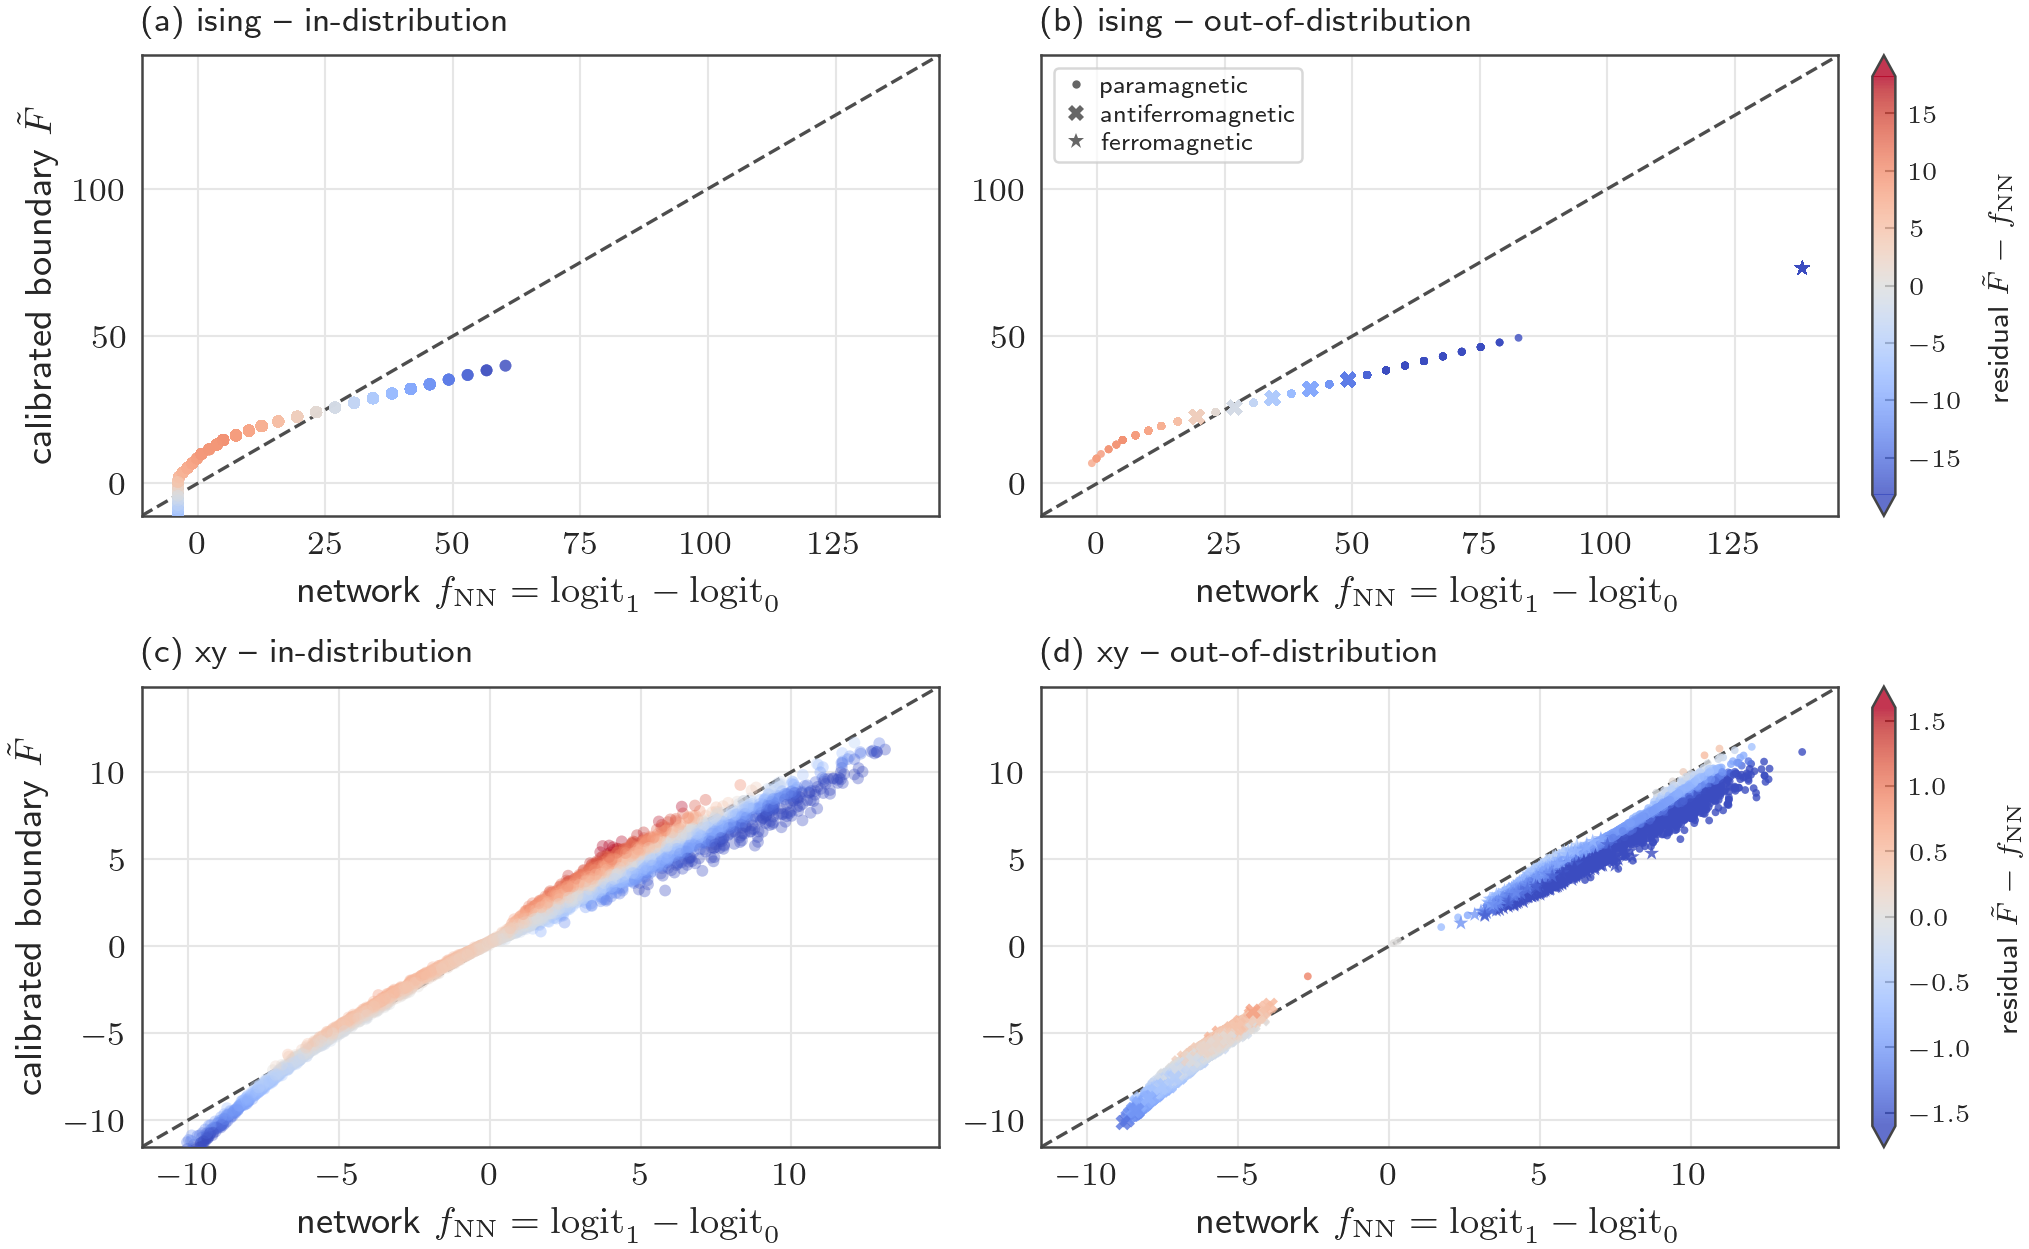

In [24]:
import matplotlib as mpl
from mpl_toolkits.axes_grid1 import make_axes_locatable

plt.style.use(PAPER_MPLSTYLE)
_SINGLE_WIDTH = 3.4
_DOUBLE_WIDTH = 6.80914
_GOLDEN = (1 + np.sqrt(5)) / 2

QUOTED_PIPE = {"ising": FORWARD["ising"]["fit"]["pipe"], "xy": FORWARD["xy"]["fit"]["pipe"]}

fig, axs = plt.subplots(2, 2, figsize=(_DOUBLE_WIDTH, _DOUBLE_WIDTH / _GOLDEN))

for row, m in enumerate(["ising", "xy"]):
    pipe = QUOTED_PIPE[m]
    X_val, y_val = latent_matrix(m)
    signed_val = pipe.decision_function(X_val)
    logit_val = net_logit_diff(DATA[m]["out"])
    a, b = np.polyfit(signed_val, logit_val, 1)
    calib_val = a * signed_val + b
    err_val = calib_val - logit_val

    fam_marker = [("paramagnetic", "."), ("antiferromagnetic", "X"), ("ferromagnetic", "*")]
    calib_gen, logit_gen, err_gen = {}, {}, {}
    for fam, _ in fam_marker:
        raw = OOD_RAW[m][fam]
        X_gen = raw["z"][:, LATENT[m]]
        signed_gen = pipe.decision_function(X_gen)
        logit_gen[fam] = net_logit_diff(raw["out"])
        calib_gen[fam] = a * signed_gen + b
        err_gen[fam] = calib_gen[fam] - logit_gen[fam]

    all_err = np.concatenate([err_val] + [err_gen[f] for f, _ in fam_marker])
    norm = mpl.colors.Normalize(*(v * float(np.percentile(np.abs(all_err), 90)) for v in (-1, 1)))
    cmap = "coolwarm"

    all_x = np.concatenate([logit_val] + [logit_gen[f] for f, _ in fam_marker])
    all_y = np.concatenate([calib_val] + [calib_gen[f] for f, _ in fam_marker])
    lo, hi = float(all_x.min()), float(all_x.max())
    pad = 0.05 * (hi - lo)

    ax = axs[row, 0]
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", lw=0.8, color="0.3", zorder=1)
    ax.scatter(logit_val, calib_val, c=err_val, cmap=cmap, norm=norm, s=8, linewidths=0, alpha=0.35, zorder=3)
    ax.set_title(f"({'ac'[row]}) {m} – in-distribution", loc="left", fontsize=8)
    ax.set_ylabel(r"calibrated boundary $\tilde F$")

    ax = axs[row, 1]
    ax.plot([lo - pad, hi + pad], [lo - pad, hi + pad], ls="--", lw=0.8, color="0.3", zorder=1)
    sc = None
    for fam, marker in fam_marker:
        sc = ax.scatter(logit_gen[fam], calib_gen[fam], c=err_gen[fam], cmap=cmap, norm=norm,
                         marker=marker, s=14, linewidths=0, alpha=0.8, zorder=3, label=fam)
    ax.set_title(f"({'bd'[row]}) {m} – out-of-distribution", loc="left", fontsize=8)
    if row == 0:
        handles = [plt.Line2D([], [], ls="none", marker=mk, ms=4, markerfacecolor="0.4",
                              markeredgecolor="none", label=f) for f, mk in fam_marker]
        ax.legend(handles=handles, loc="upper left", fontsize=6, framealpha=0.75)

    for ax in axs[row, :]:
        ax.set_xlim(lo - pad, hi + pad)
        ax.set_ylim(lo - pad, hi + pad)
        ax.set_xlabel(r"network $f_{\rm NN}=\mathrm{logit}_1-\mathrm{logit}_0$")

    cbar = fig.colorbar(sc, ax=axs[row, :], extend="both", fraction=0.05, pad=0.02)
    cbar.set_label(r"residual $\tilde F - f_{\rm NN}$", fontsize=7)
    cbar.ax.tick_params(labelsize=6)

fig.savefig(OUTDIR / "Fig6_ood_2col.pdf")
print(f"wrote {OUTDIR / 'Fig6_ood_2col.pdf'}")